<a href="https://colab.research.google.com/github/DRzaid-tech/MLREH2/blob/main/CyberClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install catboost

In [ ]:
from itertools import product

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from joblib import delayed, Parallel
from sklearn.neural_network import MLPClassifier
from tqdm import tqdm
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, f1_score
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
# Data Manipulation
import pandas as pd
import numpy as np

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

# Additional Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report
)

data_directory = "/content/drive/MyDrive/dataset"
realLife = data_directory+'/Real_life'
simulation = data_directory+"/Simulation"

In [ ]:
!pip install  --upgrade openpyxl

In [ ]:
!pwd
!ls

/content
catboost_info  drive  global_data.csv  sample_data


In [ ]:
!pip install --upgrade openpyxl pandas

In [ ]:
#lecture du dossier dexcel


def get_dataframe(directory):
    # Créer un DataFrame vide pour stocker toutes les données
    combined_data = pd.DataFrame()

    for file in os.listdir(directory):
        # Construire le chemin complet du fichier
        file_path = os.path.join(directory, file)

        # Charger le fichier Excel
        try:
            data = pd.read_excel(file_path)
        except Exception as e:
            print(f"Erreur lors du chargement du fichier {file_path}: {e}")
            continue

        # Normaliser les noms de colonnes (renommer "Label" quelle que soit sa variation)
        for col in data.columns:
            if "Label:" in col:
                data.rename(columns={col: "Label"}, inplace=True)
                break  # Une fois renommé, sortez de la boucle

        # Ajouter les données au DataFrame global
        combined_data = pd.concat([combined_data, data], ignore_index=True)

    return combined_data

def load_data(simulation=simulation , realLife=realLife, binary=True , shuffle = False , split = True):
    # Charger les données
    df = get_dataframe(simulation)
    df_real = get_dataframe(realLife)

    # Définir les colonnes des caractéristiques
    features = ['IRTT', 'TTOC', 'MITR', 'MATR', 'NROC', 'ARP poisoning indicator']

    if binary:
        # Transformer la colonne 'Label' en binaire
        df['Binary_Label'] = df['Label'].apply(lambda x: 1 if x != 1 else 0)
        df_real['Binary_Label'] = df_real['Label'].apply(lambda x: 1 if x != 1 else 0)

        # Supprimer les valeurs manquantes
        df.dropna(subset=features + ['Binary_Label'], inplace=True)
        df_real.dropna(subset=features + ['Binary_Label'], inplace=True)

        target = 'Binary_Label'

    else:
        # Filtrer les données selon les labels
        target = 'Label'

    # Sélectionner les caractéristiques et la cible
    if shuffle and split:
        global_df = pd.concat([df, df_real], ignore_index=True)
        global_df = global_df.sample(frac=1, random_state=42).reset_index(drop=True)
        X = global_df[features]
        y = global_df[target]
        X_train , X_test , y_train , y_test = train_test_split(X, y, test_size=0.3, random_state=42)

        return X_train, y_train, X_test, y_test


    if not split and not shuffle:
        return df , df_real
    elif not split and shuffle:
        global_df = pd.concat([df, df_real], ignore_index=True)
        global_df = global_df.sample(frac=1, random_state=42).reset_index(drop=True)
        return global_df
    else:
        X_simu = df[features]
        y_simu = df[target]
        X_real = df_real[features]
        y_real = df_real[target]
        return X_simu, y_simu, X_real, y_real


In [ ]:
global_data = load_data(simulation, realLife, binary=False, split=False, shuffle=True)

In [ ]:
global_data.describe()


,IRTT,TTOC,MITR,MATR,NROC,ARP poisoning indicator,Label
count,11187.000000,11187.000000,11187.000000,11187.000000,11188.000000,11188.000000,11188.000000
mean,0.011653,0.201032,0.009900,0.028065,9.493386,0.185645,315.205399
std,0.018945,0.155486,0.006925,0.026508,3.500125,0.388838,612.211853
min,0.002613,0.034919,0.001381,0.004145,6.000000,0.000000,1.000000
25%,0.005359,0.092826,0.003964,0.014223,6.000000,0.000000,1.000000
50%,0.007710,0.160147,0.009257,0.020688,6.000000,0.000000,1.000000
75%,0.012926,0.237378,0.012102,0.039138,13.000000,0.000000,500.000000
max,0.905813,2.847636,0.038235,1.078053,14.000000,1.000000,2000.000000


In [ ]:

# Mapping dictionary
label_mapping = {
    1: "Normal",
    1000: "MITM attacking controller",
    2000: "MITM attacking router",
    500: "MITM two-way attack",
    50: "Unknown MITM attack"
}

# Inverse mapping dictionary
inverse_mapping = {v: k for k, v in label_mapping.items()}

# Map the column to string labels
global_data["Label"] = global_data["Label"].astype('int').map(label_mapping)



# # Display the resulting DataFrame with the new columns
# print("DataFrame with new columns:")
# print(df)

# # Remove the newly added columns
# df = df.drop(columns=["Mapped Label", "Inverse Mapped Label"])

# Display the resulting DataFrame after removing the new columns
# print("\nDataFrame after removing new columns:")
# print(df)

In [ ]:
global_data["Label"].unique()

array(['Normal', 'MITM attacking router', 'MITM two-way attack',
       'MITM attacking controller', 'Unknown MITM attack'], dtype=object)

In [ ]:
def plot_label_distribution(data, label_col='Label'):
    """
    Generate a pie chart for the percentage distribution of the label column in the dataset.

    Parameters:
    - data: pd.DataFrame, the dataset containing the label column.
    - label_col: str, the column name of the label.
    """
    # Calculate the percentage distribution of each label
    label_counts = data[label_col].value_counts(normalize=True) * 100

    # Plot the pie chart
    plt.figure(figsize=(10, 10))
    label_counts.plot.pie(
        autopct='%1.1f%%',
        startangle=90,
        cmap='tab10',
        legend=True, fontsize=16,
        labels=label_counts.index
    )
    plt.title('Label Distribution (%)', fontsize=16)
    plt.ylabel('')  # Remove default ylabel for clarity
    plt.show()

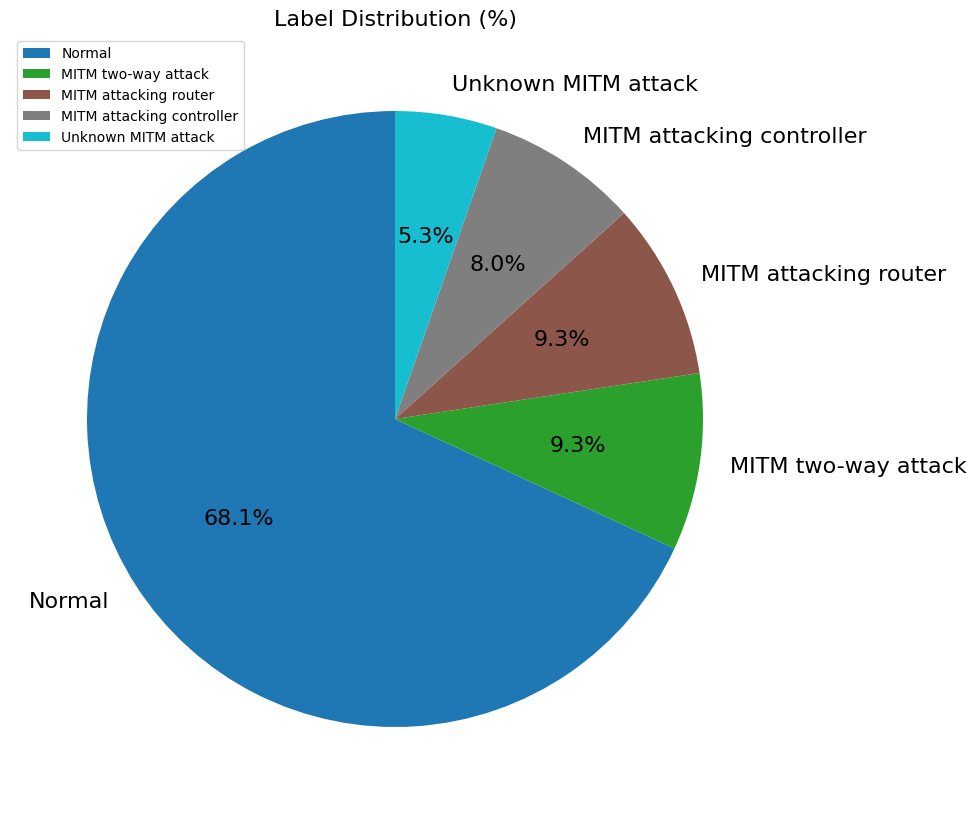

In [ ]:
plot_label_distribution(global_data, label_col='Label')

In [ ]:
global_data.to_csv('global_data.csv', index=False)

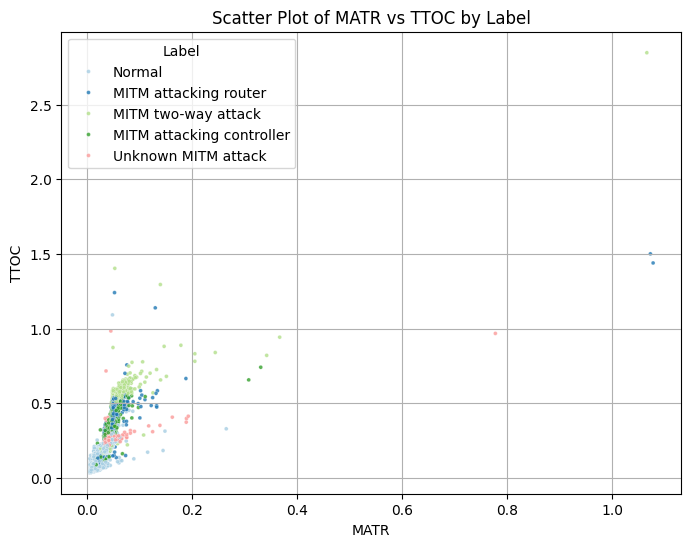

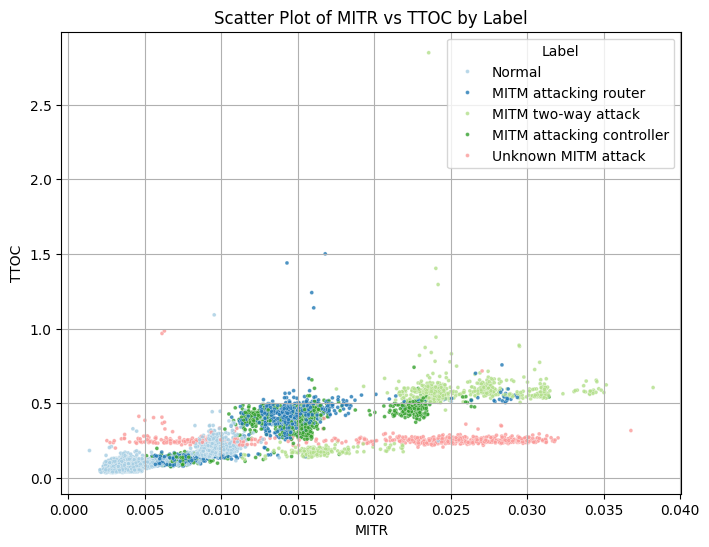

In [ ]:
# Generate additional graphs focused on 'Label'
#
# # 1. Boxplot for each variable grouped by 'Label'
# for column in global_data.columns[:-1]:  # Exclude 'Label' itself
#     plt.figure(figsize=(12, 6))
#     global_data.boxplot(column=column, by='Label', grid=False, showfliers=False)
#     plt.title(f'Boxplot of {column} by Label')
#     plt.suptitle("")  # Suppress default title
#     plt.xlabel('Label')
#     plt.ylabel(column)
#     plt.xticks(rotation=90)
#     plt.show()
#
# # 2. Bar chart for mean values of numeric columns by 'Label'
# mean_values = global_data.groupby('Label').mean()
#
# for column in global_data.columns[:-1]:  # Exclude 'Label' itself
#     plt.figure(figsize=(12, 6))
#     mean_values[column].plot(kind='bar', alpha=0.7)
#     plt.title(f'Average {column} by Label')
#     plt.xlabel('Label')
#     plt.ylabel(f'Mean {column}')
#     plt.xticks(rotation=90)
#     plt.grid(axis='y')
#     plt.show()
#
# # 3. Scatter matrix for key variables grouped by 'Label'
# from pandas.plotting import scatter_matrix
#
# key_columns = global_data.columns[:-1]  # All except 'Label'
# scatter_matrix(global_data[key_columns], figsize=(15, 10), alpha=0.5, diagonal='kde')
# plt.suptitle('Scatter Matrix of Key Variables Grouped by Label')
# plt.show()
#

# 4. scatter plot for each pair of variables
# mettre des couleur differente pour chaque label
pair_list = [('MATR','TTOC'),('MITR','TTOC')]
for pair in pair_list:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=global_data, x=pair[0], y=pair[1], hue='Label', alpha=0.8, s=8,
                    palette='Paired', legend='full')
    plt.title(f'Scatter Plot of {pair[0]} vs {pair[1]} by Label')
    plt.xlabel(pair[0])
    plt.ylabel(pair[1])
    plt.grid(True)
    plt.show()


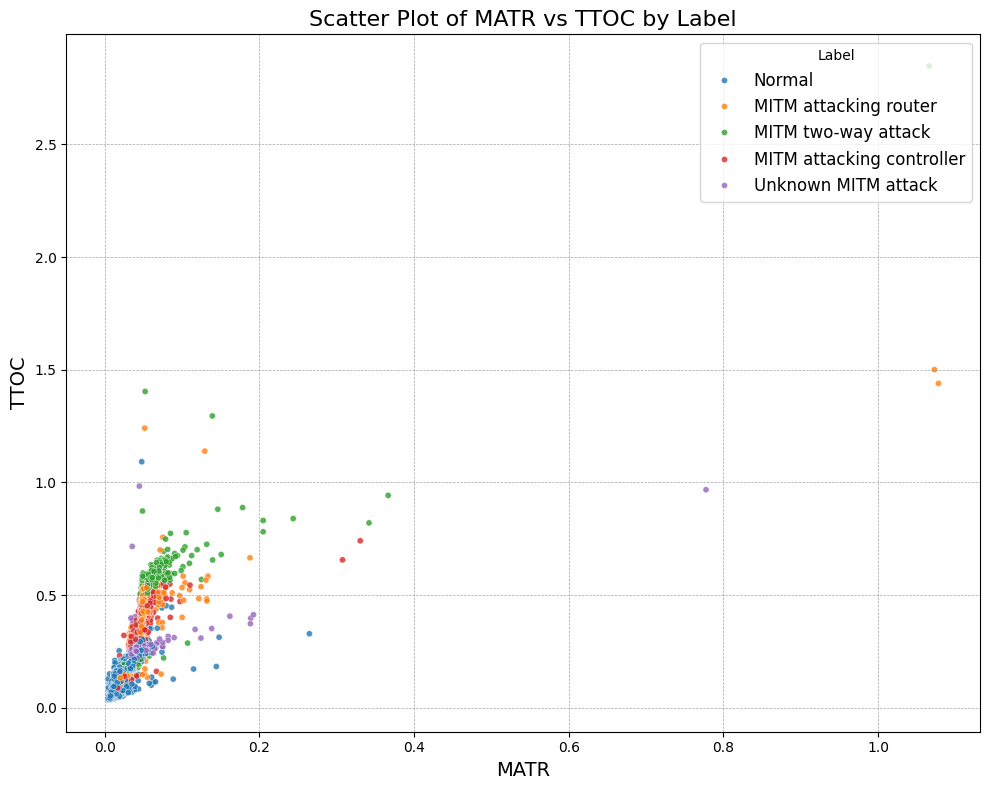

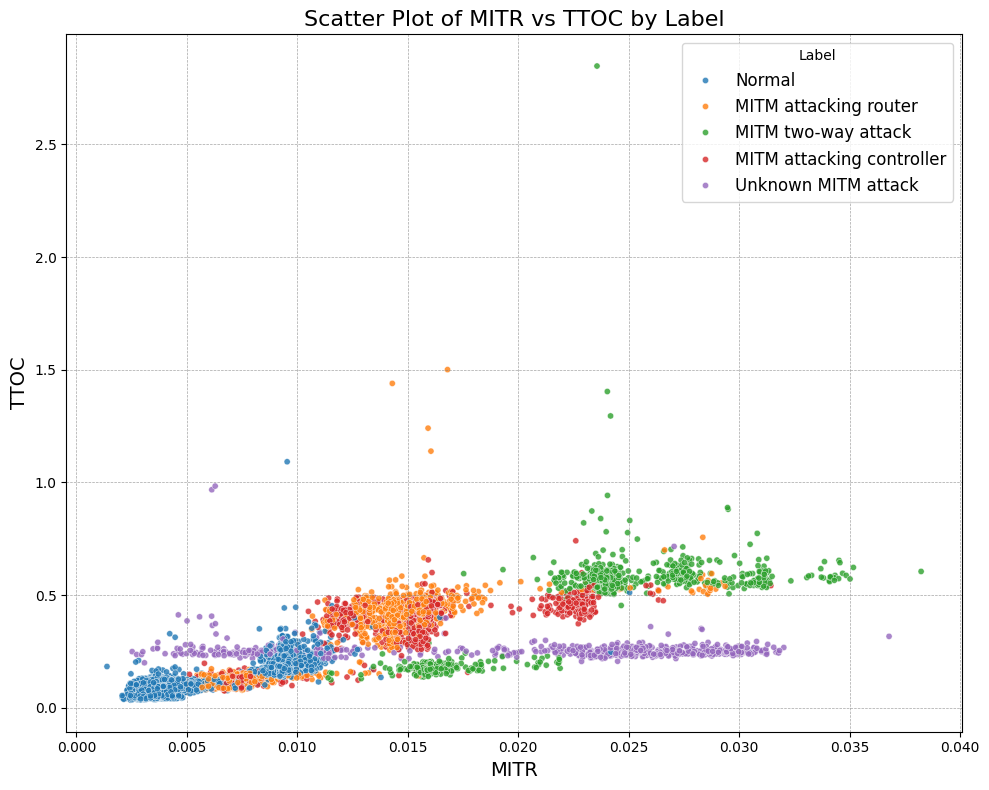

In [ ]:
# List of variable pairs to plot
pair_list = [('MATR', 'TTOC'), ('MITR', 'TTOC')]

# Custom palette for better visualization
custom_palette = sns.color_palette("tab10", n_colors=global_data['Label'].nunique())

# Generate scatter plots for each pair
for pair in pair_list:
    plt.figure(figsize=(10, 8))  # Larger figure size for clarity
    sns.scatterplot(
        data=global_data,
        x=pair[0],
        y=pair[1],
        hue='Label',
        alpha=0.8,
        s=20,  # Slightly larger marker size for visibility
        palette=custom_palette,
        legend='full'
    )
    plt.title(f'Scatter Plot of {pair[0]} vs {pair[1]} by Label', fontsize=16)
    plt.xlabel(pair[0], fontsize=14)
    plt.ylabel(pair[1], fontsize=14)
    plt.legend(title='Label', loc='upper right', fontsize=12)  # Improved legend placement
    plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)  # Subtle grid for readability
    # plt.yscale('log')
    plt.tight_layout()  # Adjust layout to avoid overlapping
    plt.show()

In [ ]:
def plot_boxplots(data, label_col='Label'):
    """
    Generate boxplots for all numeric features in the DataFrame grouped by the label column.

    Parameters:
    - data: pd.DataFrame, the dataset containing features and labels.
    - label_col: str, the column name of the label (used for grouping).
    """
    # Select numeric columns only
    numeric_features = data.select_dtypes(include=['float64', 'int64']).columns.tolist()

    # Remove the label column if it's numeric
    if label_col in numeric_features:
        numeric_features.remove(label_col)

    # Plot boxplots for each numeric feature
    for feature in numeric_features:
        plt.figure(figsize=(12, 8))
        sns.boxplot(data=data, x=label_col, y=feature, palette='Set3')
        plt.title(f'Boxplot of {feature} by {label_col}', fontsize=16)
        plt.xlabel(label_col, fontsize=14)
        plt.ylabel(feature, fontsize=14)
        plt.xticks(rotation=90, ha='right', fontsize=14)
        plt.yticks(rotation=0, ha='right', fontsize=14)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.yscale('log')
        plt.tight_layout()  # Adjust layout to avoid overlap

        plt.show()

<ipython-input-157-8884cddac2af>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=label_col, y=feature, palette='Set3')


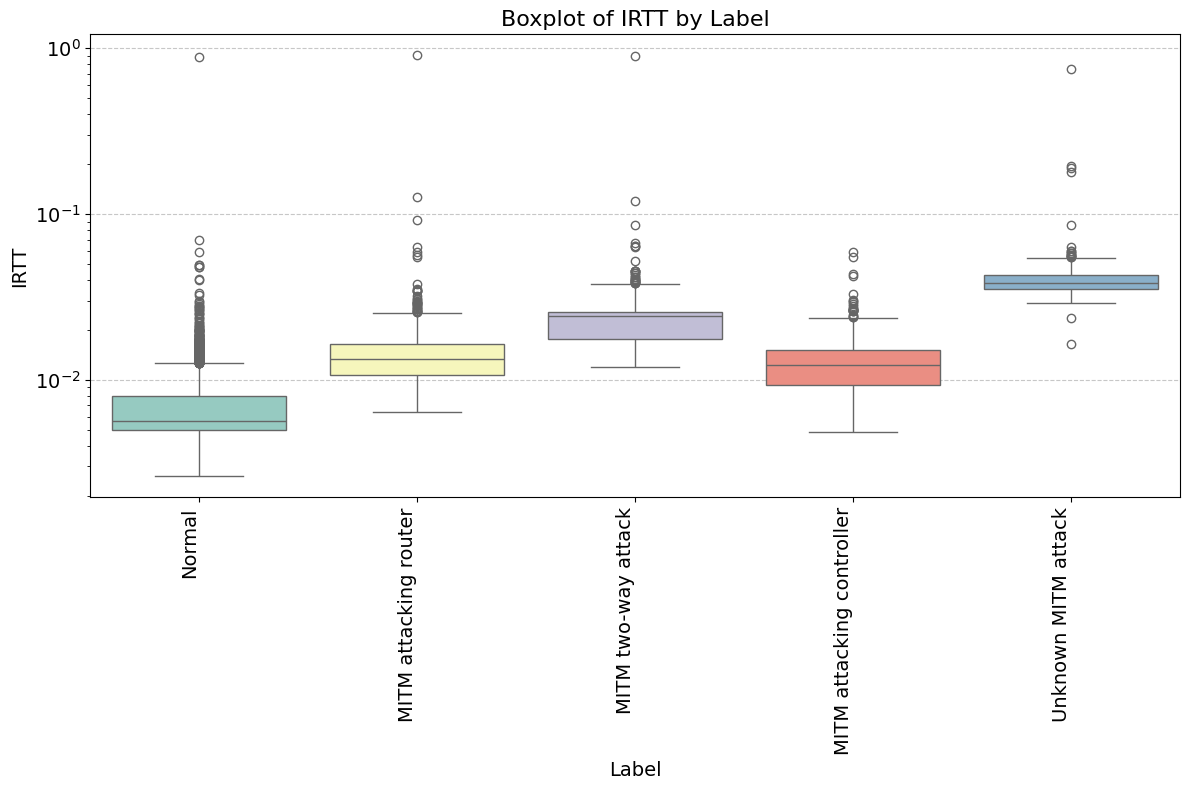

<ipython-input-157-8884cddac2af>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=label_col, y=feature, palette='Set3')


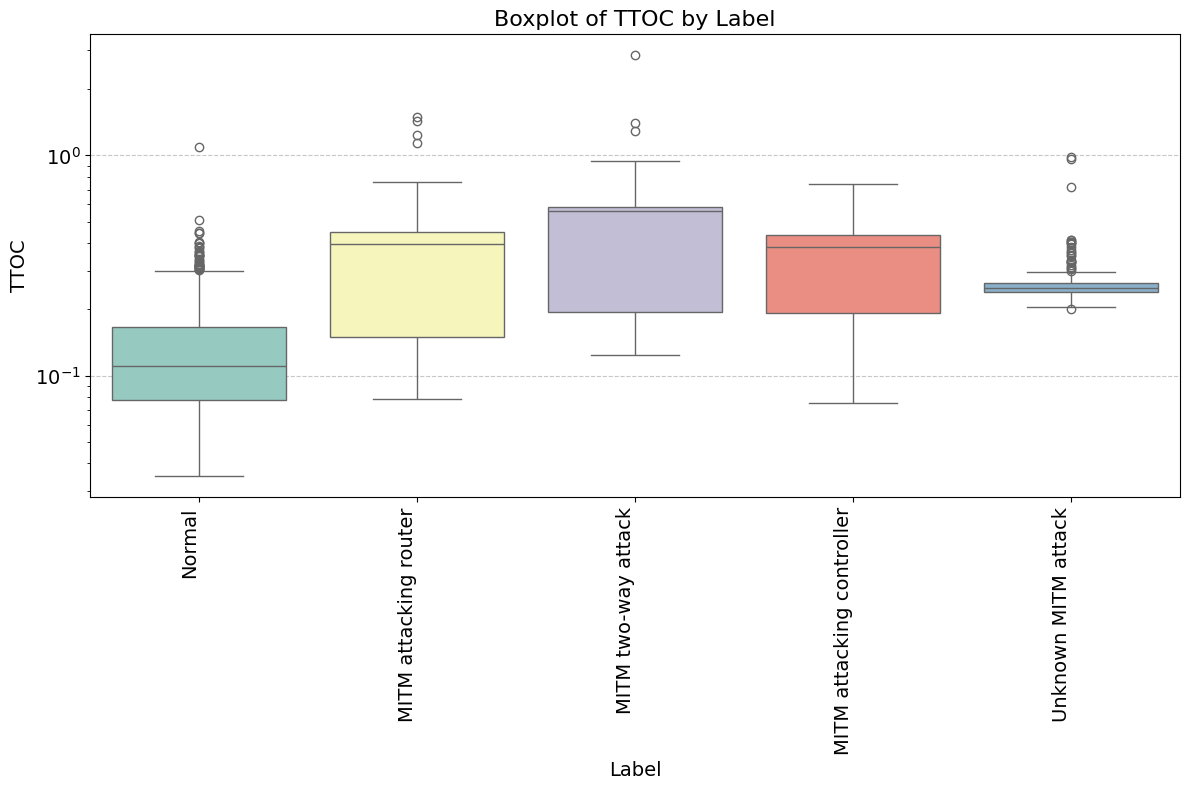

<ipython-input-157-8884cddac2af>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=label_col, y=feature, palette='Set3')


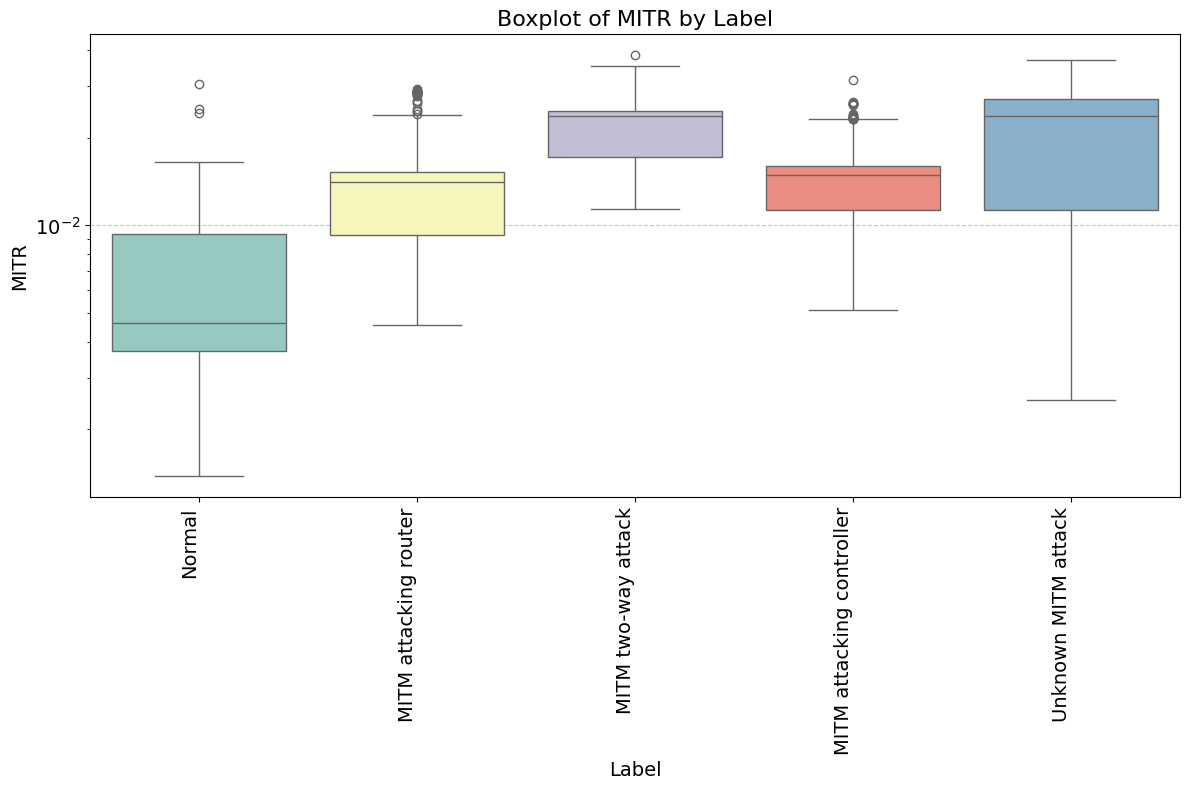

<ipython-input-157-8884cddac2af>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=label_col, y=feature, palette='Set3')


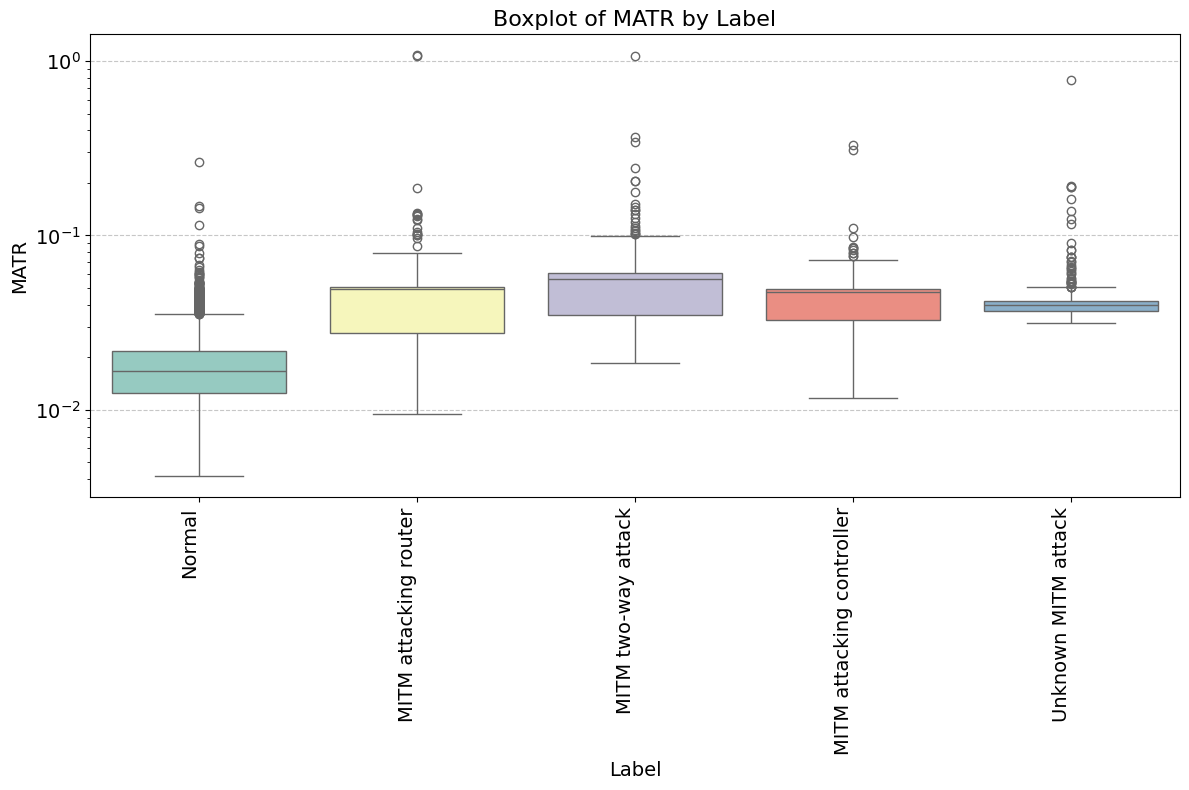

<ipython-input-157-8884cddac2af>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=label_col, y=feature, palette='Set3')


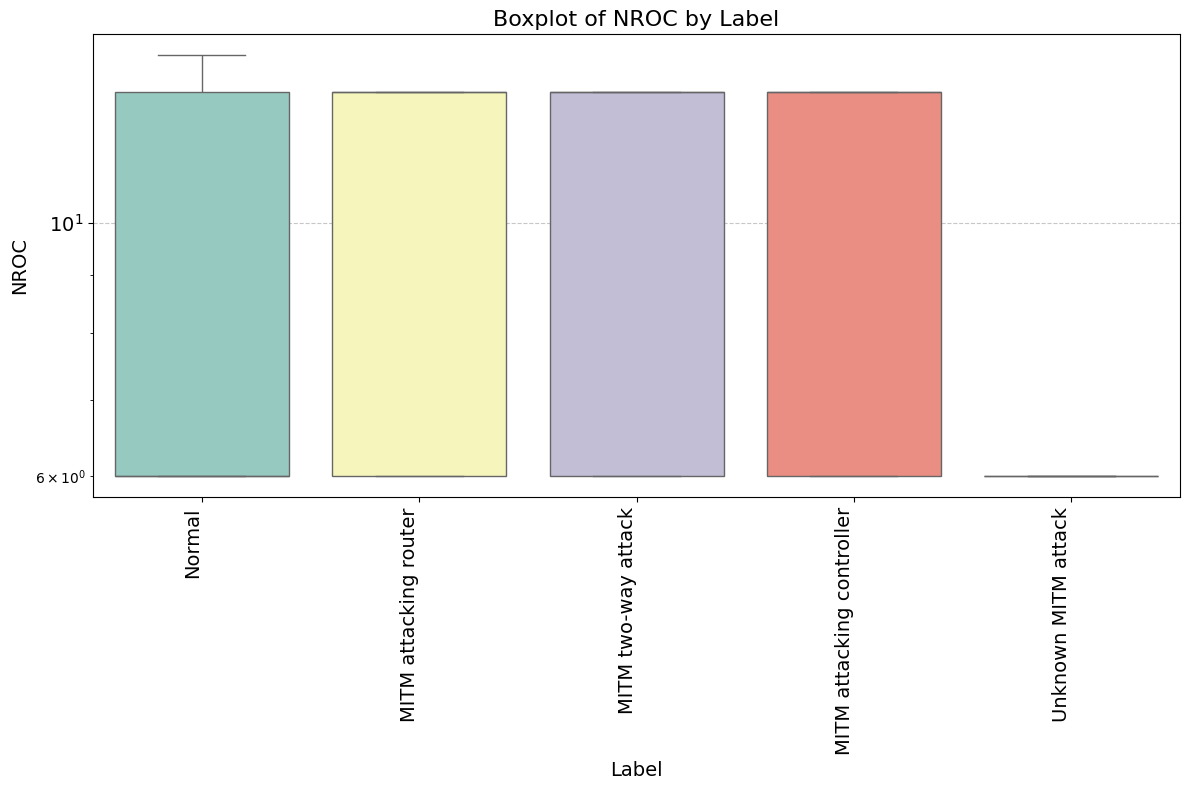

<ipython-input-157-8884cddac2af>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=label_col, y=feature, palette='Set3')


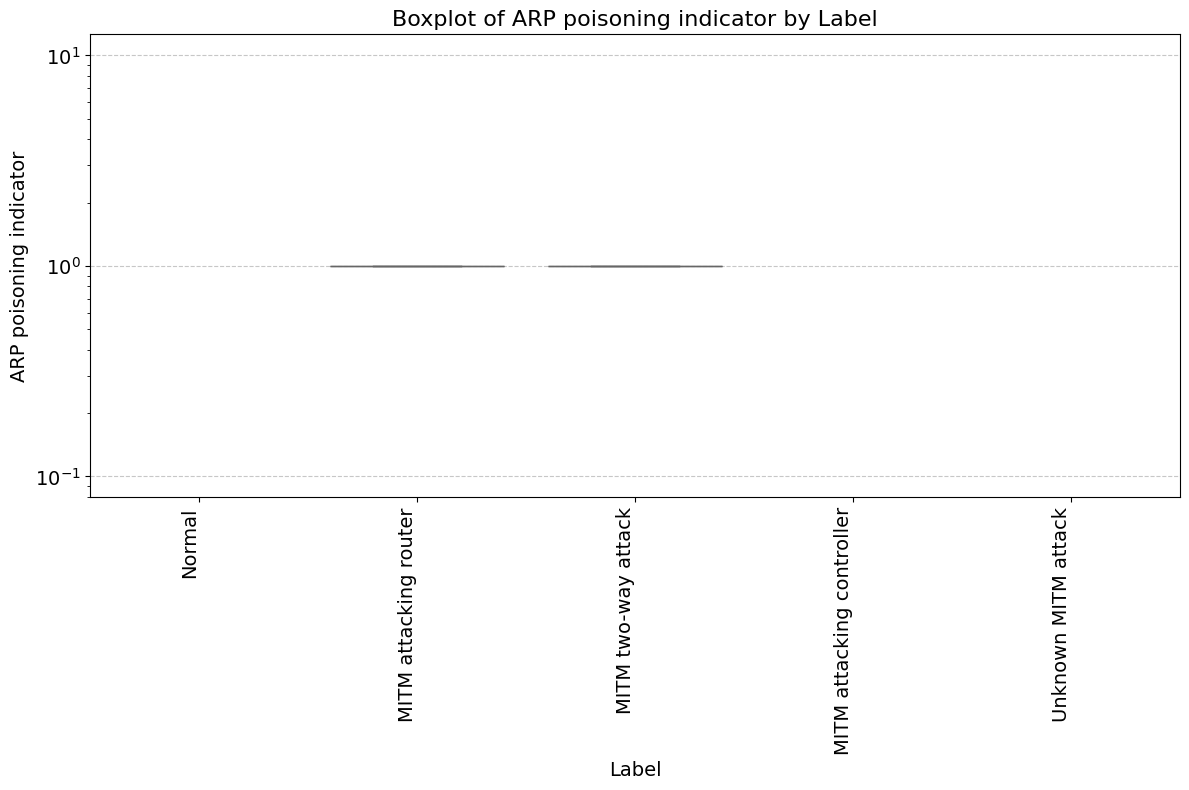

In [ ]:
plot_boxplots(global_data, label_col='Label')

In [ ]:
def plot_boxplots_in_one_figure(data):
    """
    Generate boxplots for all numeric features in the DataFrame in a single figure.

    Parameters:
    - data: pd.DataFrame, the dataset containing features.
    """
    # Select numeric columns only
    numeric_features = data.select_dtypes(include=['float64', 'int64']).columns.tolist()

    # Prepare data for seaborn boxplot
    melted_data = data[numeric_features].melt(var_name='Feature', value_name='Value')

    # Plot all features in one figure
    plt.figure(figsize=(14, 8))  # Adjust figure size as needed
    sns.boxplot(data=melted_data, x='Feature', y='Value', palette='Set3')
    plt.title('Boxplots of All Numeric Features', fontsize=16)
    plt.xlabel('Features', fontsize=14)
    plt.ylabel('Values', fontsize=14)
    plt.xticks(rotation=45, fontsize=10)  # Rotate feature names for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=90, ha='right', fontsize=14)
    plt.yticks(rotation=0, ha='right', fontsize=14)
    plt.tight_layout()  # Adjust layout to avoid overlap
    plt.yscale('log')
    plt.show()

<ipython-input-159-ffe41ec2c133>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted_data, x='Feature', y='Value', palette='Set3')


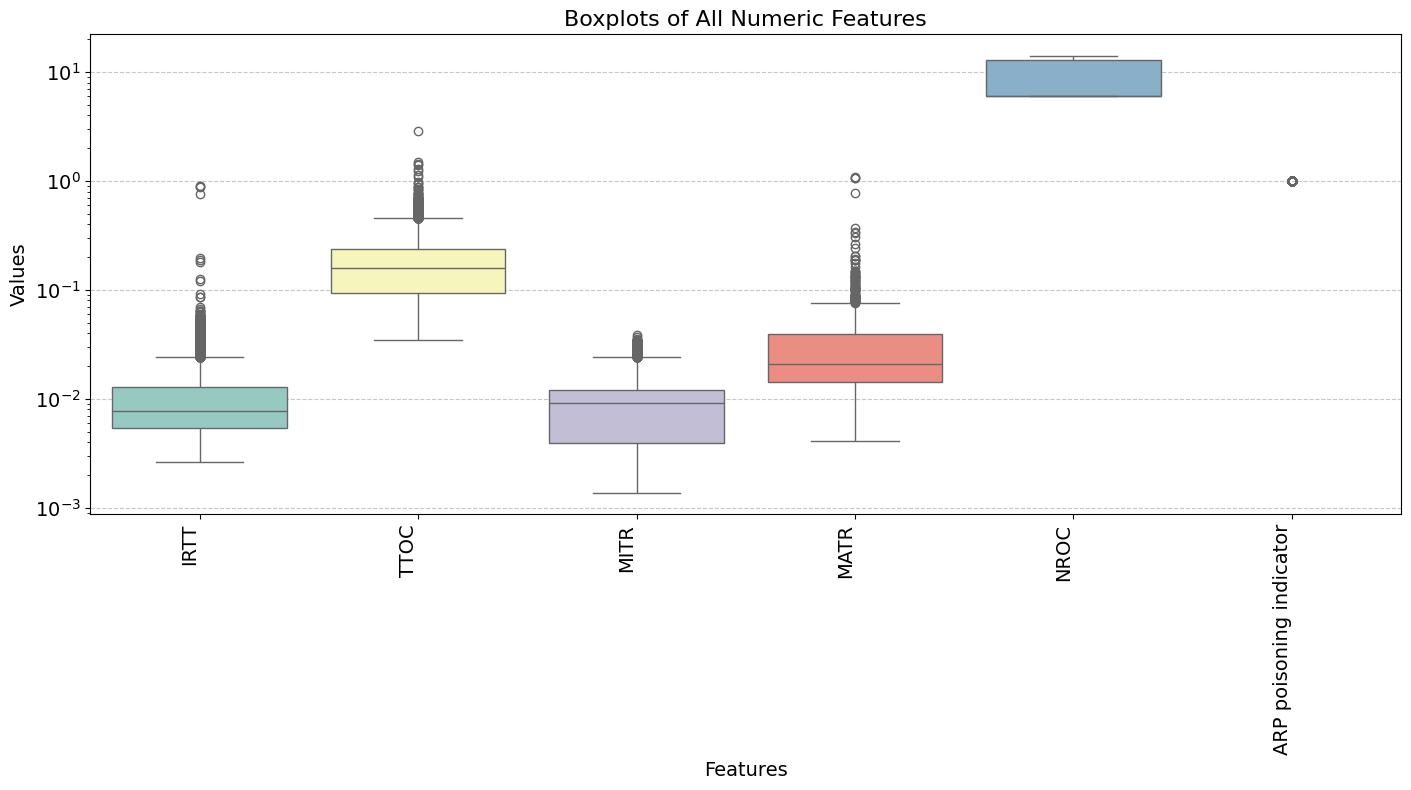

In [ ]:
plot_boxplots_in_one_figure(global_data)

In [ ]:
def plot_pairplot(data, label_col='Label'):
    """
    Generate a pairplot for all numeric features in the DataFrame, colored by the label column.

    Parameters:
    - data: pd.DataFrame, the dataset containing features and labels.
    - label_col: str, the column name of the label (used for coloring).
    """
    # Select numeric features and the label column
    numeric_features = data.select_dtypes(include=['float64', 'int64']).columns.tolist()

    # Ensure the label column is included
    if label_col not in numeric_features:
        numeric_features.append(label_col)

    # Create pairplot
    pairplot = sns.pairplot(data[numeric_features], hue=label_col, diag_kind='kde', corner=True)
    pairplot.fig.suptitle('Pairplot of Numeric Features Colored by Label', y=1.02, fontsize=16)
    plt.show()

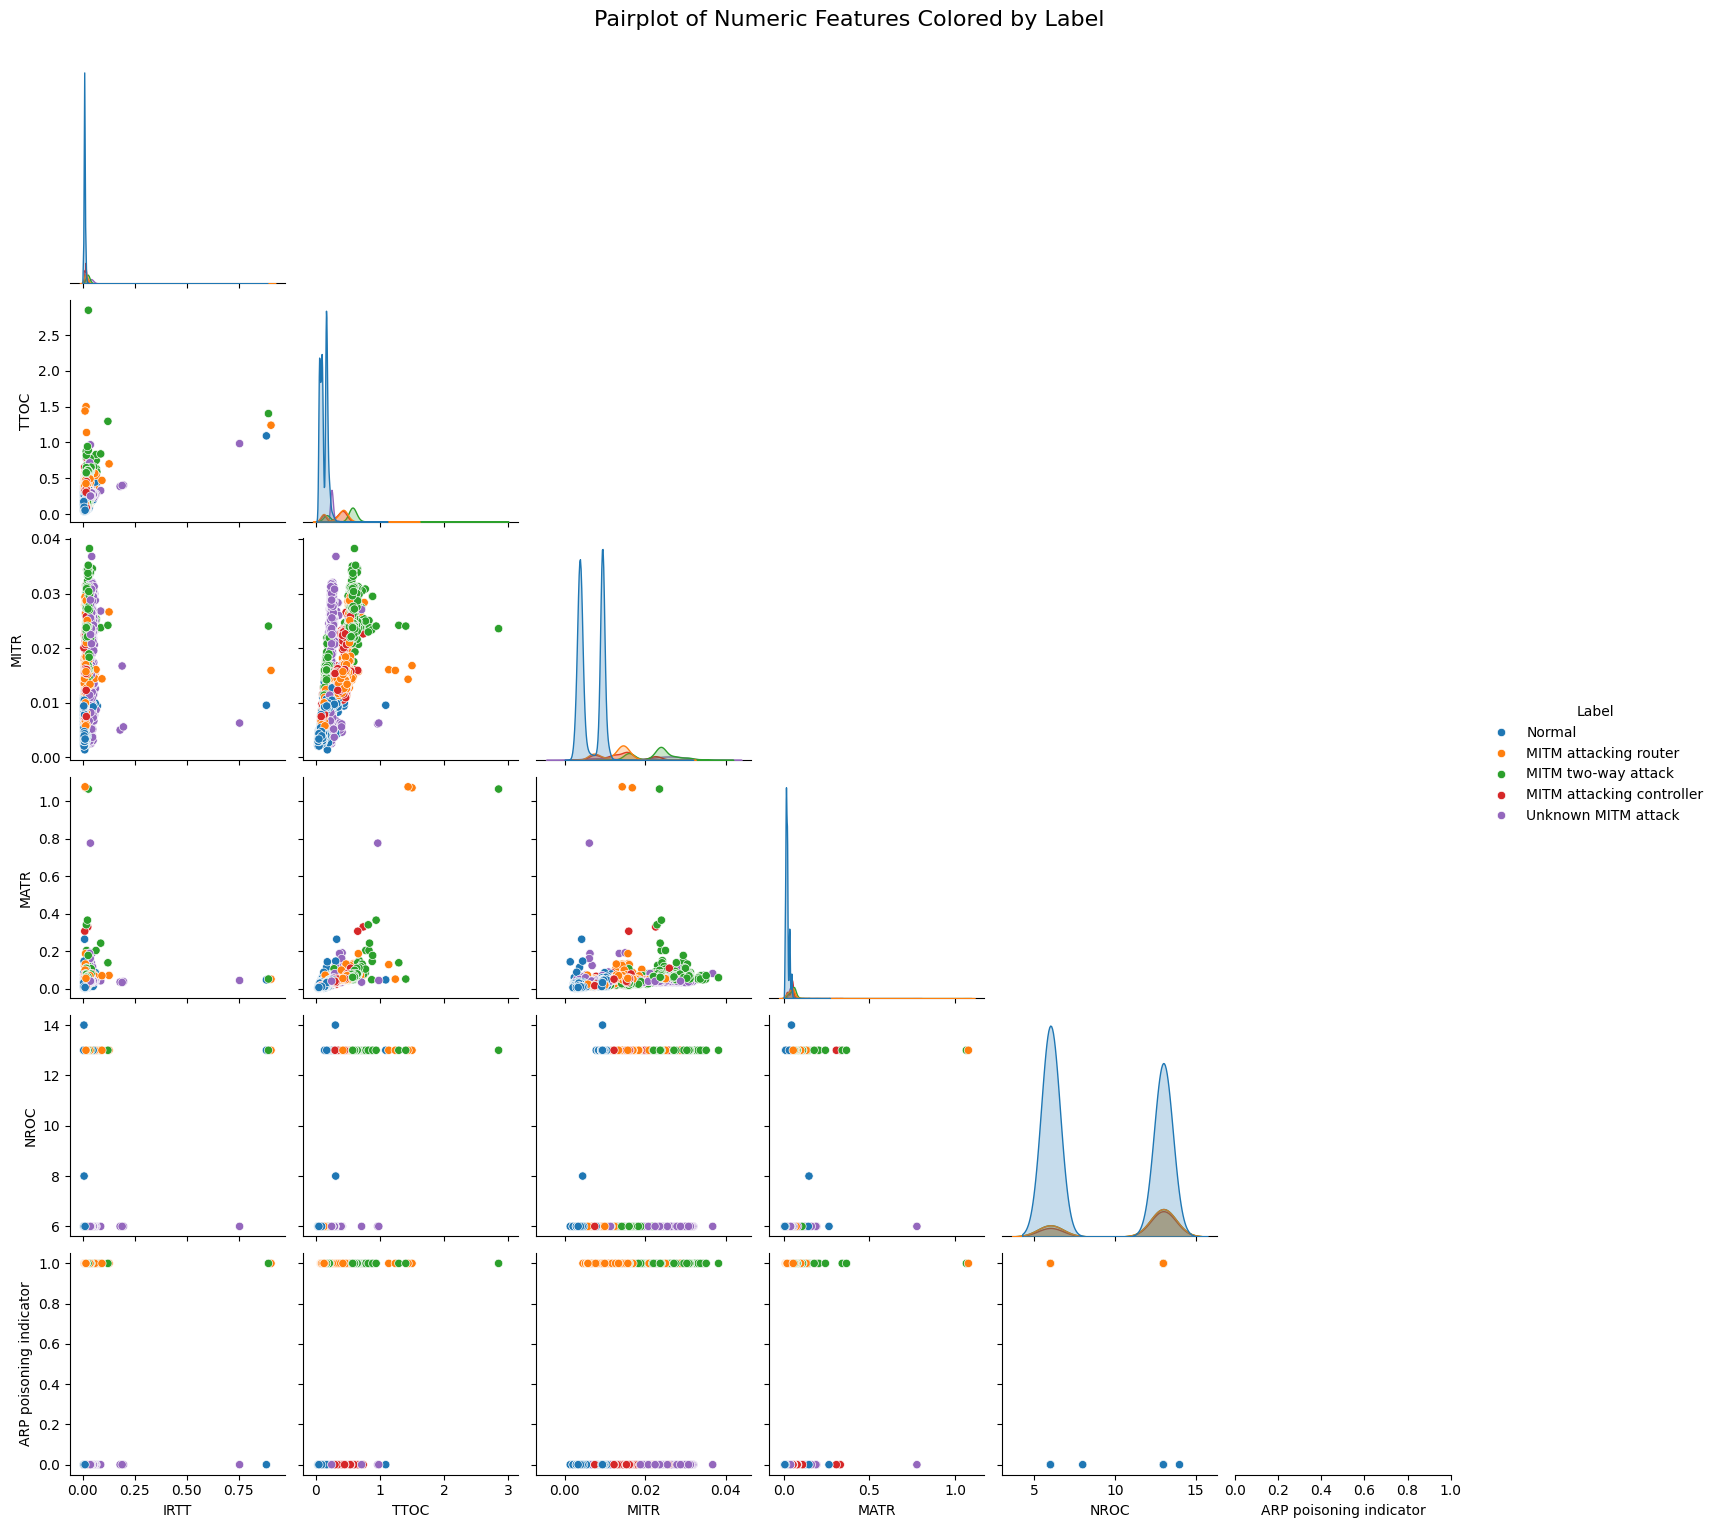

In [ ]:
plot_pairplot(global_data, label_col='Label')

In [ ]:
# Map back the string labels to numeric values
global_data["Label"] =global_data["Label"].map(inverse_mapping)

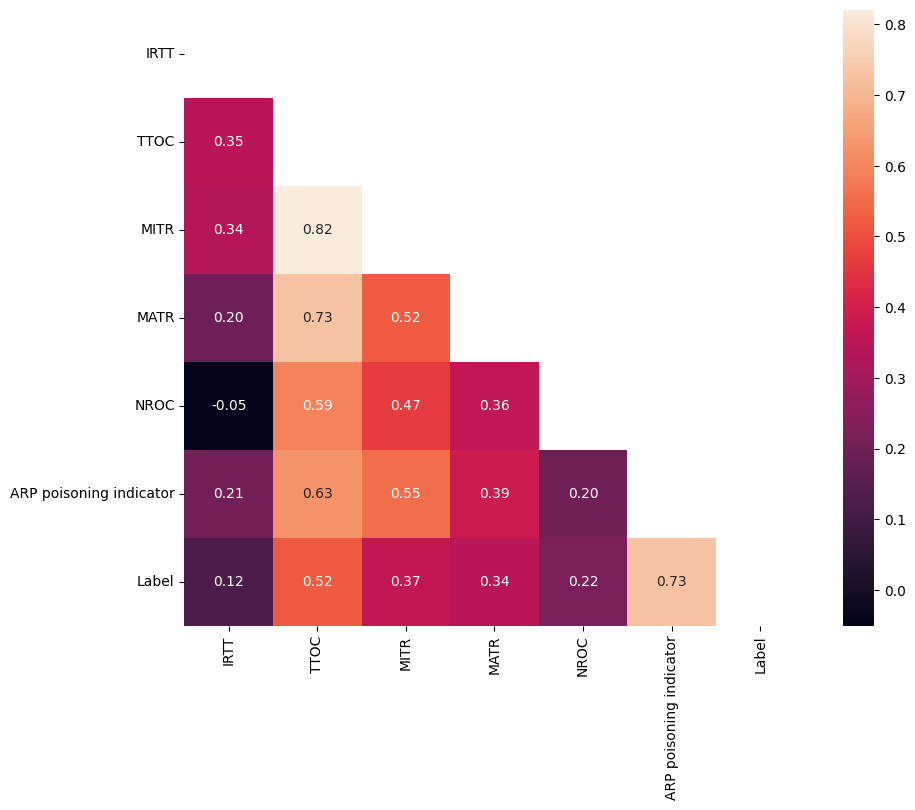

In [ ]:
correlation_matrix = global_data.corr()

# Créer un masque pour la moitié supérieure
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Ajuster la taille de la figure
plt.figure(figsize=(10, 8))

# Dessiner la heatmap avec le masque
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cbar=True)

# Ajouter un titre
# plt.title("Matrice de corrélation global")
plt.show()

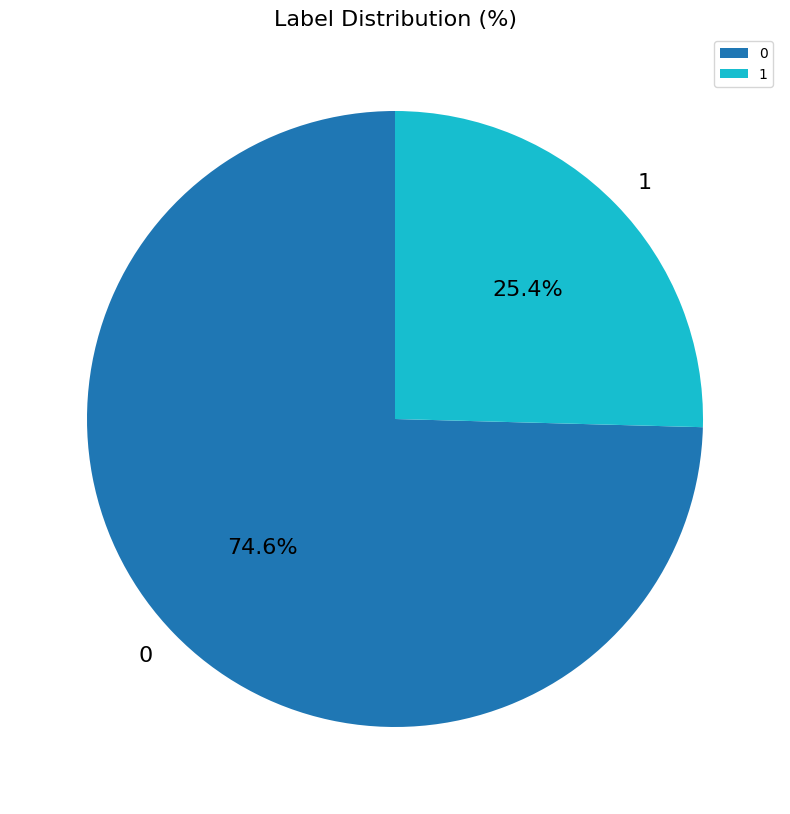

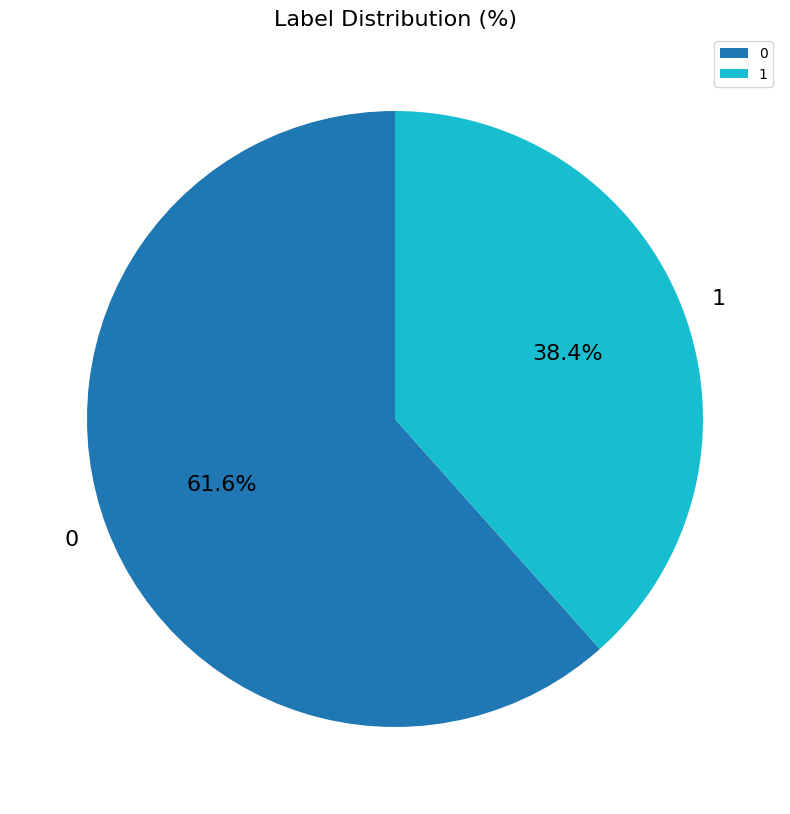

nombre de ligne de df simulation: (5604, 8)
nombre de ligne de df_real (5583, 8)


In [ ]:
df = get_dataframe(simulation)
df_real = get_dataframe(realLife)

# Transformer la colonne 'Label' en binaire
df['Binary_Label'] = df['Label'].apply(lambda x: 1 if x != 1 else 0)
df_real['Binary_Label'] = df_real['Label'].apply(lambda x: 1 if x != 1 else 0)

plot_label_distribution(df, label_col='Binary_Label')
plot_label_distribution(df_real, label_col='Binary_Label')
# Supprimer les valeurs manquantes
df.dropna(inplace=True)
df_real.dropna(inplace=True)

print("nombre de ligne de df simulation:",df.shape)
print("nombre de ligne de df_real",df_real.shape)


Testing model: Random Forest


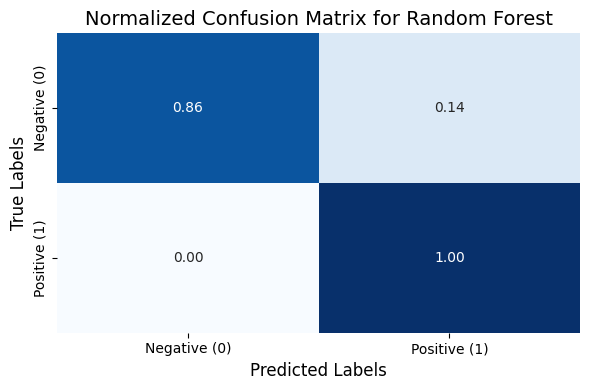


Testing model: Extra Trees


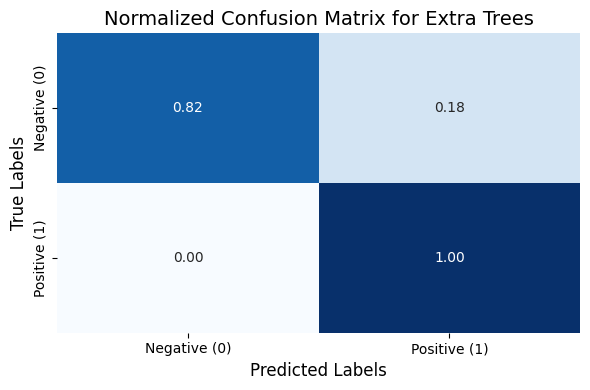


Testing model: Logistic Regression


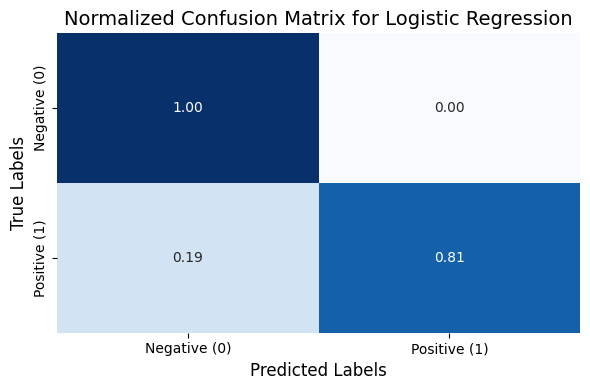


Testing model: SVM


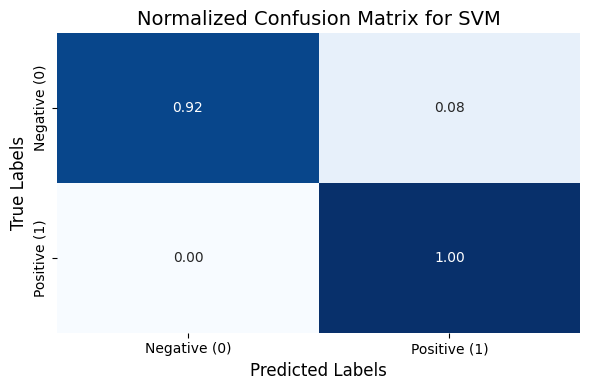


Testing model: K-Nearest Neighbors


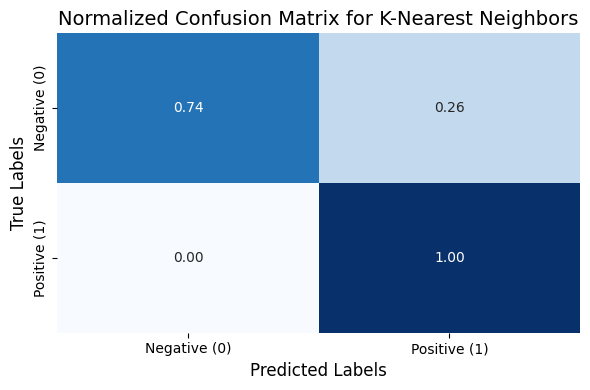


Testing model: Decision Tree


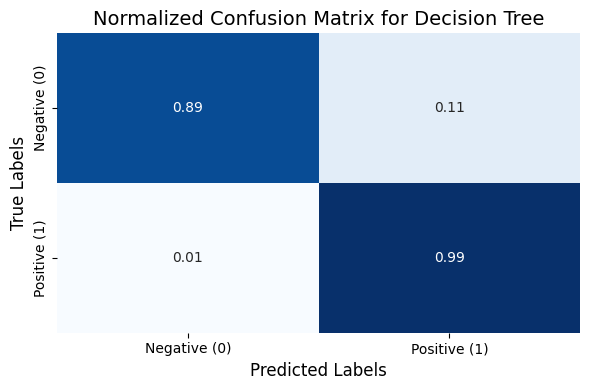


Testing model: MLP


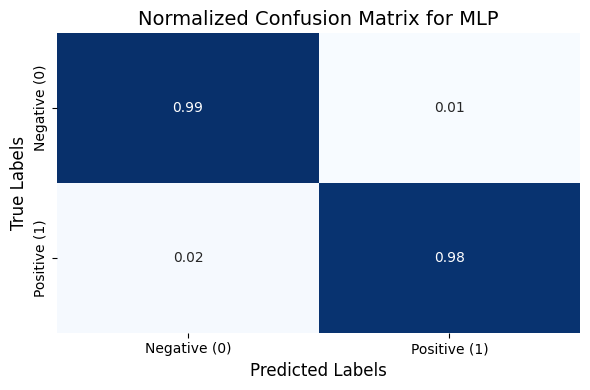


Testing model: XGBoost


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [15:53:06] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


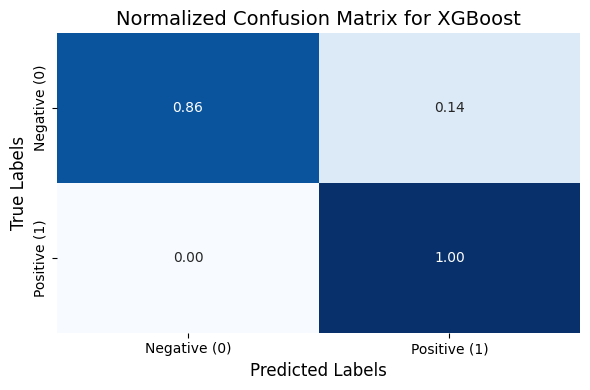


Testing model: LightGBM
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1425, number of negative: 4179
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000556 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1022
[LightGBM] [Info] Number of data points in the train set: 5604, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.254283 -> initscore=-1.075900
[LightGBM] [Info] Start training from score -1.075900
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


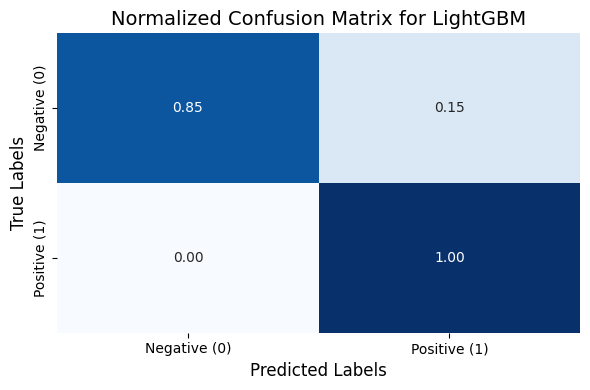


Testing model: CatBoost


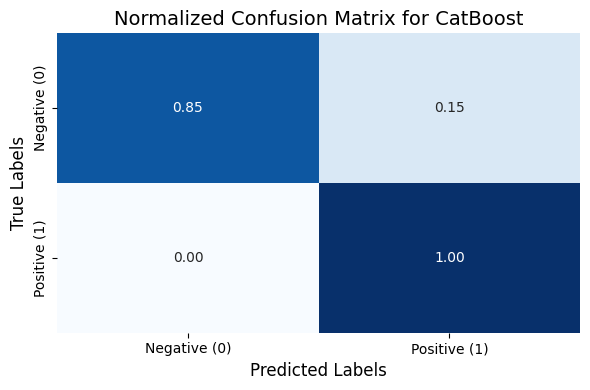


Overall Results (Sorted by FNR and FPR):
                 Model  Accuracy  Precision (1)  Recall (1)  F1 Score  \
0                  MLP  0.986029       0.986353    0.977156  0.981733   
1                  SVM  0.948415       0.881628    1.000000  0.937090   
2        Decision Tree  0.926205       0.843440    0.992075  0.911740   
3  Logistic Regression  0.925309       0.997123    0.807925  0.892609   
4              XGBoost  0.914025       0.817869    0.998601  0.899244   
5        Random Forest  0.910980       0.812358    0.999068  0.896090   
6             LightGBM  0.909009       0.808519    1.000000  0.894123   
7             CatBoost  0.905785       0.803525    0.999068  0.890690   
8          Extra Trees  0.888411       0.774928    1.000000  0.873194   
9  K-Nearest Neighbors  0.838796       0.704568    0.999534  0.826523   

            Normalized Confusion Matrix  
0  [[0.9916, 0.0084], [0.0228, 0.9772]]  
1        [[0.9162, 0.0838], [0.0, 1.0]]  
2  [[0.8851, 0.1149], [0.007

,Model,Accuracy,Precision (1),Recall (1),F1 Score,Normalized Confusion Matrix
0,MLP,0.986029,0.986353,0.977156,0.981733,"[[0.9916, 0.0084], [0.0228, 0.9772]]"
1,SVM,0.948415,0.881628,1.000000,0.937090,"[[0.9162, 0.0838], [0.0, 1.0]]"
2,Decision Tree,0.926205,0.843440,0.992075,0.911740,"[[0.8851, 0.1149], [0.0079, 0.9921]]"
3,Logistic Regression,0.925309,0.997123,0.807925,0.892609,"[[0.9985, 0.0015], [0.1921, 0.8079]]"
4,XGBoost,0.914025,0.817869,0.998601,0.899244,"[[0.8613, 0.1387], [0.0014, 0.9986]]"
5,Random Forest,0.910980,0.812358,0.999068,0.896090,"[[0.856, 0.144], [0.0009, 0.9991]]"
6,LightGBM,0.909009,0.808519,1.000000,0.894123,"[[0.8522, 0.1478], [0.0, 1.0]]"
7,CatBoost,0.905785,0.803525,0.999068,0.890690,"[[0.8476, 0.1524], [0.0009, 0.9991]]"
8,Extra Trees,0.888411,0.774928,1.000000,0.873194,"[[0.8188, 0.1812], [0.0, 1.0]]"
9,K-Nearest Neighbors,0.838796,0.704568,0.999534,0.826523,"[[0.7385, 0.2615], [0.0005, 0.9995]]"


In [ ]:
# def test_models_with_normalized_confusion_matrix(simulation, realLife):
#     # Charger les données
#     df = get_dataframe(simulation)
#     df_real = get_dataframe(realLife)

#     # Transformer la colonne 'Label' en binaire
#     df['Binary_Label'] = df['Label'].apply(lambda x: 1 if x != 1 else 0)
#     df_real['Binary_Label'] = df_real['Label'].apply(lambda x: 1 if x != 1 else 0)

#     # Supprimer les valeurs manquantes
#     df.dropna(inplace=True)
#     df_real.dropna(inplace=True)


#     # Sélectionner les colonnes
#     features = ['IRTT', 'TTOC', 'MITR', 'MATR', 'NROC', 'ARP poisoning indicator']
#     target = 'Binary_Label'

#     # Diviser les données
#     X_simu = df[features]
#     y_simu = df[target]
#     X_real = df_real[features]
#     y_real = df_real[target]


#     # Définir les modèles à tester
#     models = {
#         "Random Forest": RandomForestClassifier(random_state=42),
#         "Logistic Regression": LogisticRegression(),
#         "SVM": SVC(),
#         "K-Nearest Neighbors": KNeighborsClassifier(),
#         "Decision Tree": DecisionTreeClassifier(random_state=42),
#         # "MLP_tunning": MLPClassifier(random_state=42, max_iter=5000, hidden_layer_sizes=(90,20), activation='tanh', solver='adam', alpha=0.001, learning_rate='adaptive'),
#         # "MLP tunning": MLPClassifier(random_state=42, max_iter=5000, hidden_layer_sizes=(100,10,20), activation='tanh', solver='adam', alpha=0.001, learning_rate='adaptive'),
#         "MLP": MLPClassifier(random_state=42, max_iter=5000),
#         "XGBoost": XGBClassifier( eval_metric='logloss'),
#         "catboost": CatBoostClassifier()
#     }

#     # Résultats
#     results = []

#     for name, model in models.items():
#         print(f"\nTesting model: {name}")

#         # Entraîner le modèle sur les données simulées
#         model.fit(X_simu, y_simu)

#         # Prédire sur les données réelles
#         y_pred = model.predict(X_real)

#         # Calculer les métriques
#         accuracy = accuracy_score(y_real, y_pred)
#         f1 = f1_score(y_real, y_pred)
#         cm = confusion_matrix(y_real, y_pred)
#         cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normaliser par ligne

#         report = classification_report(y_real, y_pred, output_dict=True)

#         # Sauvegarder les résultats
#         results.append({
#             "Model": name,
#             "Accuracy": accuracy,
#             "F1 Score": f1,
#             "Precision (1)": report['1']['precision'],
#             "Recall (1)": report['1']['recall']
#         })

#         # Afficher la matrice de confusion normalisée
#         plot_normalized_confusion_matrix(cm_normalized, name)

#     # Convertir les résultats en DataFrame
#     results_df = pd.DataFrame(results)

#     # Afficher les résultats
#     print("\nOverall Results:")

#     return results_df


def test_models_with_normalized_confusion_matrix(simulation, realLife):
    """
    Test multiple models on simulated and real-life datasets, evaluate performance metrics,
    including False Positive and False Negative Rates, sorted by these metrics.

    Parameters:
    - simulation: Path or object for the simulation dataset.
    - realLife: Path or object for the real-life dataset.

    Returns:
    - A DataFrame of model results sorted by False Negative Rate in ascending order.
    """
    # Charger les données
    df = get_dataframe(simulation)
    df_real = get_dataframe(realLife)

    # Transformer la colonne 'Label' en binaire
    df['Binary_Label'] = df['Label'].apply(lambda x: 1 if x != 1 else 0)
    df_real['Binary_Label'] = df_real['Label'].apply(lambda x: 1 if x != 1 else 0)

    # Supprimer les valeurs manquantes
    df.dropna(inplace=True)
    df_real.dropna(inplace=True)

    # Sélectionner les colonnes
    features = ['IRTT', 'TTOC', 'MITR', 'MATR', 'NROC', 'ARP poisoning indicator']
    target = 'Binary_Label'

    # Diviser les données
    X_simu = df[features]
    y_simu = df[target]
    X_real = df_real[features]
    y_real = df_real[target]

    # Définir les modèles à tester
    models = {
        "Random Forest": RandomForestClassifier(random_state=42),
        "Extra Trees": ExtraTreesClassifier(random_state=42),
        "Logistic Regression": LogisticRegression(),
        "SVM": SVC(),
        "K-Nearest Neighbors": KNeighborsClassifier(),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "MLP": MLPClassifier(random_state=42, max_iter=5000),
        "XGBoost": XGBClassifier(eval_metric='logloss', use_label_encoder=False),
        "LightGBM": LGBMClassifier(),
        "CatBoost": CatBoostClassifier(verbose=0)  # Suppress verbose output for CatBoost
    }

    # Résultats
    results = []

    for name, model in models.items():
        print(f"\nTesting model: {name}")

        # Entraîner le modèle sur les données simulées
        model.fit(X_simu, y_simu)

        # Prédire sur les données réelles
        y_pred = model.predict(X_real)

        # Calculer les métriques
        accuracy = accuracy_score(y_real, y_pred)
        f1 = f1_score(y_real, y_pred)
        cm_normalized  = confusion_matrix(y_real, y_pred,normalize='true')
        # cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normaliser par ligne
        # cm_normalized_rounded = np.round(cm_normalized, 4)  # Round to 4 decimal places

        # Extract FPR and FNR from the normalized confusion matrix
        # cm_normalized = [[TN_rate, FP_rate], [FN_rate, TP_rate]]
        fpr = cm_normalized[0, 1]  # False Positive Rate
        fnr = cm_normalized[1, 0]  # False Negative Rate

        report = classification_report(y_real, y_pred, output_dict=True)

        # Sauvegarder les résultats
        results.append({
            "Model": name,
            "Accuracy": accuracy,
            "Precision (1)": report['1']['precision'],
            "Recall (1)": report['1']['recall'],
            "F1 Score": f1,
            "Normalized Confusion Matrix": np.round(cm_normalized,4).tolist()  # Store normalized CM as a list
            # "False Positive Rate (FPR)": fpr,
            # "False Negative Rate (FNR)": fnr
        })

        # Afficher la matrice de confusion normalisée
        plot_normalized_confusion_matrix(cm_normalized, name)

    # Convertir les résultats en DataFrame
    results_df = pd.DataFrame(results)

    # Trier les résultats par FNR (ascending) puis FPR (ascending)
    sorted_results_df = results_df.sort_values(
        # by=["False Negative Rate (FNR)", "False Positive Rate (FPR)"],
        # ascending=[True, True]
        by=["Accuracy", "F1 Score"],
        ascending=[False, False]
    ).reset_index(drop=True)

    # Afficher les résultats triés
    print("\nOverall Results (Sorted by FNR and FPR):")
    print(sorted_results_df)

    return sorted_results_df


def plot_normalized_confusion_matrix(cm, model_name):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", cbar=False,
                xticklabels=["Negative (0)", "Positive (1)"],
                yticklabels=["Negative (0)", "Positive (1)"])
    plt.title(f"Normalized Confusion Matrix for {model_name}", fontsize=14)
    plt.xlabel("Predicted Labels", fontsize=12)
    plt.ylabel("True Labels", fontsize=12)
    plt.tight_layout()
    plt.show()
sorted_results_df=test_models_with_normalized_confusion_matrix(simulation, realLife)
sorted_results_df.head(12)

In [ ]:
sorted_results_df.to_latex()

'\\begin{tabular}{llrrrrl}\n\\toprule\n & Model & Accuracy & Precision (1) & Recall (1) & F1 Score & Normalized Confusion Matrix \\\\\n\\midrule\n0 & MLP & 0.986029 & 0.986353 & 0.977156 & 0.981733 & [[0.9916, 0.0084], [0.0228, 0.9772]] \\\\\n1 & SVM & 0.948415 & 0.881628 & 1.000000 & 0.937090 & [[0.9162, 0.0838], [0.0, 1.0]] \\\\\n2 & Decision Tree & 0.926205 & 0.843440 & 0.992075 & 0.911740 & [[0.8851, 0.1149], [0.0079, 0.9921]] \\\\\n3 & Logistic Regression & 0.925309 & 0.997123 & 0.807925 & 0.892609 & [[0.9985, 0.0015], [0.1921, 0.8079]] \\\\\n4 & XGBoost & 0.914025 & 0.817869 & 0.998601 & 0.899244 & [[0.8613, 0.1387], [0.0014, 0.9986]] \\\\\n5 & Random Forest & 0.910980 & 0.812358 & 0.999068 & 0.896090 & [[0.856, 0.144], [0.0009, 0.9991]] \\\\\n6 & LightGBM & 0.909009 & 0.808519 & 1.000000 & 0.894123 & [[0.8522, 0.1478], [0.0, 1.0]] \\\\\n7 & CatBoost & 0.905785 & 0.803525 & 0.999068 & 0.890690 & [[0.8476, 0.1524], [0.0009, 0.9991]] \\\\\n8 & Extra Trees & 0.888411 & 0.774928 & 1.

In [ ]:

def generate_hidden_layer_sizes(max_layers, max_neurons):
    """
    Génère dynamiquement des tailles pour les couches cachées.
    :param max_layers: Nombre maximum de couches.
    :param max_neurons: Nombre maximum de neurones par couche.
    :return: Liste de configurations pour hidden_layer_sizes.
    """
    hidden_layer_sizes = []
    for layers in range(1, max_layers + 1):  # De 1 à max_layers
        for size in product(range(10, max_neurons + 1, 10), repeat=layers):
            hidden_layer_sizes.append(size)
    return hidden_layer_sizes


def fine_tune_mlp_parallel(X_train, y_train, X_test, y_test):
    # Générer dynamiquement les tailles des couches cachées
    hidden_layer_sizes = generate_hidden_layer_sizes(max_layers=3, max_neurons=100)

    # Paramètres fixes
    activation_options = ['tanh']
    solver_options = ['adam']
    alpha_options = [0.001]
    learning_rate_options = ['adaptive']

    # Combinaison des hyperparamètres
    param_combinations = list(product(hidden_layer_sizes, activation_options, solver_options, alpha_options, learning_rate_options))

    print(f"Total Combinations: {len(param_combinations)}")

    # Fonction d'entraînement d'un seul modèle
    def train_model(params):
        hidden_layer, activation, solver, alpha, learning_rate = params

        # Créer le modèle avec les paramètres actuels
        mlp = MLPClassifier(
            hidden_layer_sizes=hidden_layer,
            activation=activation,
            solver=solver,
            alpha=alpha,
            learning_rate=learning_rate,
            max_iter=1000,
            random_state=42
        )

        # Entraîner le modèle et évaluer les performances
        try:
            mlp.fit(X_train, y_train)
            y_pred = mlp.predict(X_test)
            accuracy = accuracy_score(y_test, y_pred)
            return {
                'hidden_layer_sizes': hidden_layer,
                'activation': activation,
                'solver': solver,
                'alpha': alpha,
                'learning_rate': learning_rate,
                'accuracy': accuracy
            }
        except Exception as e:
            return {
                'hidden_layer_sizes': hidden_layer,
                'activation': activation,
                'solver': solver,
                'alpha': alpha,
                'learning_rate': learning_rate,
                'accuracy': -1,  # Indique une erreur
                'error': str(e)
            }

    # Exécuter en parallèle avec joblib
    results = Parallel(n_jobs=-1, verbose=10)(delayed(train_model)(params) for params in param_combinations)

    # Transformer les résultats en DataFrame
    results_df = pd.DataFrame(results)

    # Trier par précision pour afficher les meilleurs paramètres
    best_params = results_df.sort_values(by='accuracy', ascending=False).iloc[0]
    print("\nBest Parameters:")
    print(best_params)

    # Retourner les résultats
    return results_df, best_params




In [ ]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    """
    Affiche une matrice de confusion normalisée.

    Paramètres :
    y_true (array-like) : Labels réels.
    y_pred (array-like) : Labels prédits.
    model_name (str) : Nom du modèle.
    """
    # Calcul de la matrice de confusion
    cm = confusion_matrix(y_true, y_pred)

    # Normalisation de la matrice de confusion
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    class_names = np.unique(y_true)

    # Création de l'affichage de la matrice de confusion
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)

    # Tracé de la matrice de confusion
    disp.plot(cmap='Blues', values_format=".2f")
    plt.title(f"Matrice de Confusion Normalisée pour {model_name}", fontsize=14)
    plt.xlabel("Labels Prédits", fontsize=12)
    plt.ylabel("Vrais Labels", fontsize=12)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

In [ ]:


# Charger les données
X_simu, y_simu, X_real, y_real = load_data(simulation, realLife)

# Diviser les données simulées en jeu de formation et de validation
X_train, X_val, y_train, y_val = train_test_split(X_simu, y_simu, test_size=0.2, random_state=42)

# Fine-tuning et évaluation en parallèle
results_df, best_params = fine_tune_mlp_parallel(X_train, y_train, X_real, y_real)

# Visualisation des résultats
print("\nTop 5 Configurations:")
print(results_df.sort_values(by="accuracy", ascending=False).head())


Total Combinations: 1110


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   19.4s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:   53.7s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:  2.9min
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:  4.4min
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:  5.6min
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:  7.3min
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  8.9min
[Parallel(n_jobs=-1)]: Done  57 tasks      | elapsed: 10.8min
[Parallel(n_jobs=-1)]: Done  68 tasks      | elapsed: 13.1min
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed: 15.6min
[Parallel(n_jobs=-1)]: Done  94 tasks      | elapsed: 18.3min
[Parallel(n_jobs=-1)]: Done 109 tasks      | elapsed: 21.9min
[Parallel(n_jobs=-1)]: Done 124 tasks      | elapsed: 24.4min
[Parallel(n_jobs=-1)]: Done 141 tasks      | elapsed: 27

KeyboardInterrupt: 

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split





# Fonction pour définir et ajouter des modèles
def define_models():
    models = {
       "MLP_tunning": MLPClassifier(random_state=42, max_iter=5000, hidden_layer_sizes=(90,20), activation='tanh', solver='adam', alpha=0.001, learning_rate='adaptive'),
        "MLP_tunning2": MLPClassifier(random_state=42, max_iter=5000, hidden_layer_sizes=(100,10,20), activation='tanh', solver='adam', alpha=0.001, learning_rate='adaptive'),
        "MLP": MLPClassifier(random_state=42, max_iter=5000),
        "MLP_tunning3": MLPClassifier(random_state=42, max_iter=5000, hidden_layer_sizes=(100,100,100), activation='tanh', solver='adam', alpha=0.001, learning_rate='adaptive'),


    }
    return models


# Fonction pour créer un VotingClassifier
def create_voting_classifier(models):
    estimators = [(name, model) for name, model in models.items()]
    voting_clf = VotingClassifier(estimators=estimators, voting='soft')
    return voting_clf


# Fonction pour entraîner et évaluer les modèles
def train_and_evaluate(models, X_train, y_train, X_test, y_test):
    results = {}
    cms = {}
    for name, model in models.items():

        print(f"Training model: {name}")
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        accuracy = accuracy_score(y_test, predictions)
        results[name] = accuracy
        cms[name] = confusion_matrix(y_test, predictions)

        print(f"{name} Accuracy: {accuracy:.4f}")
    return results , cms

In [ ]:



# Chargement des données
X_train, y_train, X_test, y_test = load_data(simulation, realLife)

# Définition des modèles
models = define_models()

# Ajouter le VotingClassifier
voting_model = create_voting_classifier(models)
models["VotingClassifier"] = voting_model

# Entraînement et évaluation
results,cms = train_and_evaluate(models, X_train, y_train, X_test, y_test)

# Afficher les résultats
print("\nSummary of model performances:")
for model_name, accuracy in results.items():
    print(f"{model_name}: {accuracy:.4f}")
#     plot_confusion_matrix(cms[model_name], model_name)
    print(cms[model_name])


Training model: MLP_tunning
MLP_tunning Accuracy: 0.9817
Training model: MLP_tunning2
MLP_tunning2 Accuracy: 0.9858
Training model: MLP
MLP Accuracy: 0.9860
Training model: MLP_tunning3
MLP_tunning3 Accuracy: 0.9624
Training model: VotingClassifier
VotingClassifier Accuracy: 0.9873

Summary of model performances:
MLP_tunning: 0.9817
[[3339   99]
 [   3 2142]]
MLP_tunning2: 0.9858
[[3407   31]
 [  48 2097]]
MLP: 0.9860
[[3409   29]
 [  49 2096]]
MLP_tunning3: 0.9624
[[3228  210]
 [   0 2145]]
VotingClassifier: 0.9873
[[3384   54]
 [  17 2128]]


                   Feature  Importance
2                     MITR    0.681953
0                     IRTT    0.133667
1                     TTOC    0.092334
3                     MATR    0.047432
5  ARP poisoning indicator    0.044597
4                     NROC    0.000017


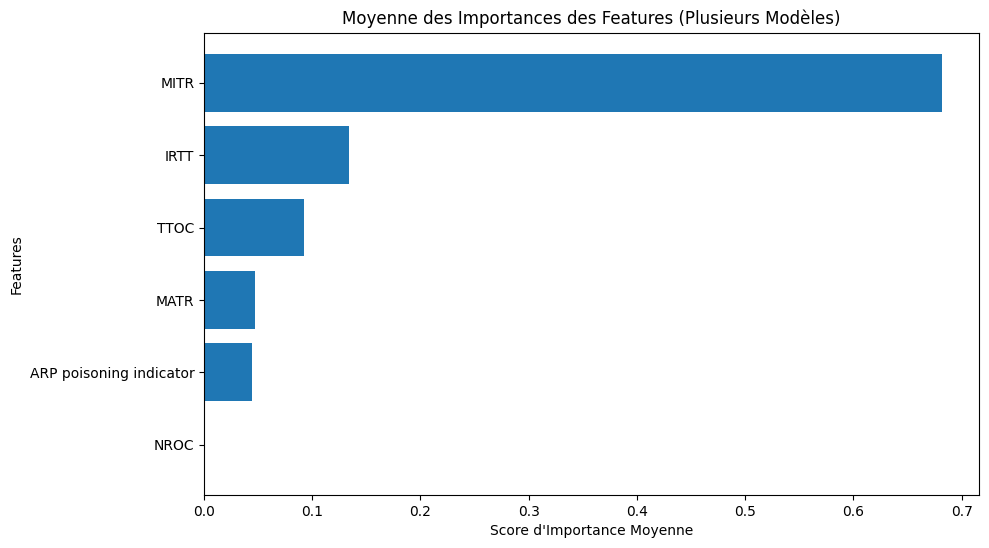

In [ ]:

# Exemple : Chargement du DataFrame
# Remplacez cette partie par votre propre DataFrame

# Diviser les données en ensembles d'entraînement et de test
X_train, y_train, X_test, y_test = load_data(simulation, realLife)

# Liste des modèles
models = [
    RandomForestClassifier(random_state=42),
    GradientBoostingClassifier(random_state=42),
    DecisionTreeClassifier(random_state=42)
]

# Calcul des importances pour chaque modèle
feature_importances = []

for model in models:
    model.fit(X_train, y_train)
    importances = model.feature_importances_
    feature_importances.append(importances)

# Moyenne des importances
mean_importances = np.mean(feature_importances, axis=0)

# Création d'un DataFrame pour visualisation
features = X_train.columns  # Utiliser les colonnes des features de X_train
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': mean_importances
}).sort_values(by='Importance', ascending=False)

# Affichage des résultats
print(feature_importance_df)

# Visualisation des importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], align='center')
plt.gca().invert_yaxis()
plt.title('Moyenne des Importances des Features (Plusieurs Modèles)')
plt.xlabel('Score d\'Importance Moyenne')
plt.ylabel('Features')
plt.show()

In [ ]:
def calculate_and_plot_feature_importance(X_train, y_train, X_test, y_test, feature_names, model_names=None):
    """
    Calculate and plot average feature importance from multiple tree-based models.

    Parameters:
    - X: Features as a DataFrame or 2D array.
    - y: Labels as a 1D array or Series.
    - feature_names: List of feature names (optional).
    - model_names: List of model names (optional).

    Returns:
    - A DataFrame with feature names and average importance.
    - A bar plot showing the average feature importance.
    """
    # Initialize and train the hybrid model
    #Mother_Tree = FFNN_TREE(input_dim=10)
    #model.fit(X_train, y_train, nn_epochs=50, nn_batch_size=10)

    # Predict and evaluate
    #y_pred = model.predict(X_test)
    #accuracy = accuracy_score(y_test, y_pred)
    #print(f'Hybrid Model Accuracy: {accuracy:.2f}')
    if model_names is None:
        model_names = [
            "Decision Tree",
            # "Mother_Tree",
            "Random Forest",
            "ExtraTrees",
            "XGBoost",
            "CatBoost",
            "LightGBM"
        ]

    # Initialize models
    models = [
        ("Decision Tree", DecisionTreeClassifier(random_state=42)),
        # ("Mother_Tree",FFNN_TREE(input_dim=10))
          ("Random Forest", RandomForestClassifier(random_state=42)),
        ("ExtraTrees", ExtraTreesClassifier(random_state=42)),
        ("XGBoost", XGBClassifier(random_state=42, use_label_encoder=False)),
        ("CatBoost", CatBoostClassifier(silent=True, random_state=42)),
        ("LightGBM", LGBMClassifier(random_state=42))
    ]

    # Dictionary to store feature importance for each model
    feature_importance = {model_name: None for model_name in model_names}

    # Fit models and store feature importance
    for model_name, model in models:
        model.fit(X_train, y_train)
        feature_importance[model_name] = model.feature_importances_/np.sum(model.feature_importances_)
    # Calculate average feature importance
    average_importance = np.mean(list(feature_importance.values()), axis=0)

    # Create a DataFrame with feature names and average importance
    average_importance_df = pd.DataFrame({'Feature': feature_names, 'Average Importance': average_importance})
    average_importance_df = average_importance_df.sort_values(by='Average Importance', ascending=False)
    print(average_importance_df.Feature)
    # Plot feature importance
    plt.figure(figsize=(16, 10))
    plt.bar(average_importance_df['Feature'], average_importance_df['Average Importance'])
    plt.ylabel('Average Importance',fontsize=18)
    plt.xlabel('Feature Name',fontsize=18)
    plt.title('Average Feature Importance from Tree-Based Models',fontsize=16)
    plt.xticks(fontsize=18,rotation=90)
    plt.yticks(fontsize=18)
    plt.grid('on')
    plt.show()

    return average_importance_df

In [ ]:
def numberOfFeatures(average_importance_df,threshold=0.85):
  for itr in range(1,average_importance_df.shape[0]):
    sum=average_importance_df['Average Importance'][:itr].sum()
    if sum>threshold:
      return itr

In [ ]:
def analyzeFeatures(X_train, y_train, X_test, y_test,features):
  average_importance_df=calculate_and_plot_feature_importance(X_train, y_train, X_test, y_test,features)
  nFeatures=numberOfFeatures(average_importance_df)
  SelectedFeatures=list(average_importance_df.Feature[:nFeatures].values)
  print(nFeatures,SelectedFeatures)
  return nFeatures,SelectedFeatures,average_importance_df

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [18:00:18] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1425, number of negative: 4179
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000878 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1022
[LightGBM] [Info] Number of data points in the train set: 5604, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.254283 -> initscore=-1.075900
[LightGBM] [Info] Start training from score -1.075900
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
2                       MITR
0                       IRTT
1                       TTOC
5    ARP poisoning indicator
3                       MATR
4                       NROC
Name: Feature, dtype: object


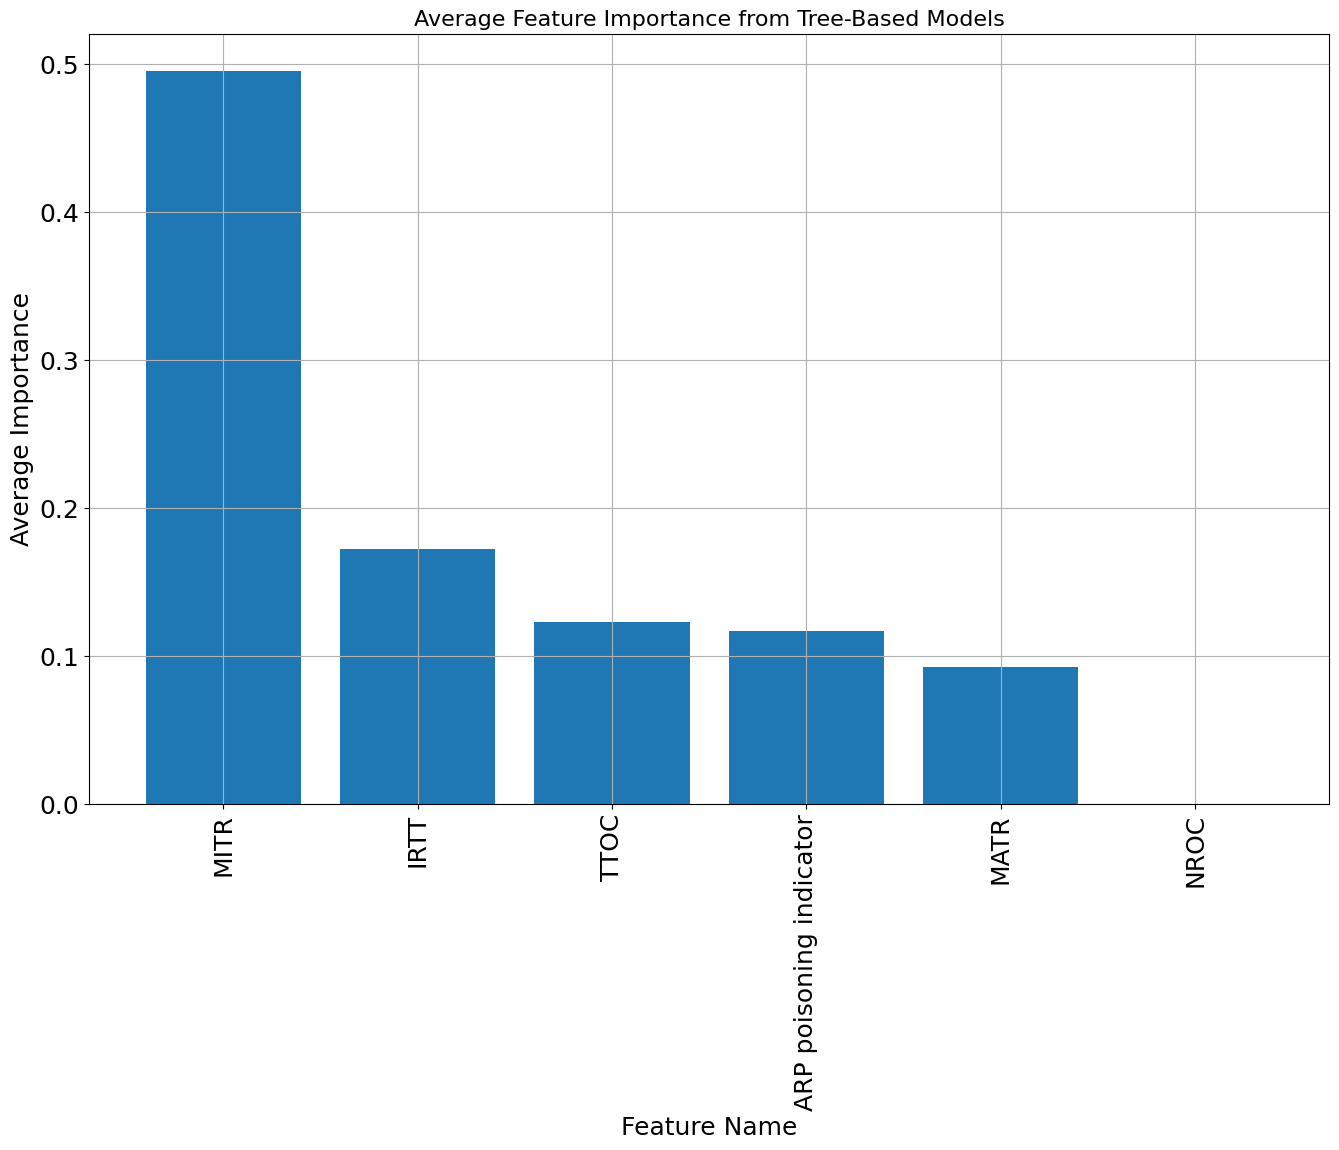

4 ['MITR', 'IRTT', 'TTOC', 'ARP poisoning indicator']
                   Feature  Average Importance
2                     MITR            0.495843
0                     IRTT            0.172100
1                     TTOC            0.122753
5  ARP poisoning indicator            0.116801
3                     MATR            0.092444
4                     NROC            0.000058


In [ ]:
# Diviser les données en ensembles d'entraînement et de test
X_train, y_train, X_test, y_test = load_data(simulation, realLife)
lnotadd=list(X_train.columns)
lnotadd
nFeatures,SelectedFeatures,average_importance_df=analyzeFeatures(X_train, y_train, X_test, y_test , features=lnotadd)
print(average_importance_df)

In [ ]:
# # Diviser les données en ensembles d'entraînement et de test
# X_train, y_train, X_test, y_test = load_data(simulation, realLife)
# binaryList=['Normal','Attack']
# results_df=perform_randomized_search2(X_train, y_train, X_test, y_test,lnotadd,led=1) # Remove the slice from lnotadd
# print(results_df.to_latex(index=False))
# print(results_df[results_df.columns[:5]].to_latex(index=False))
# results_df

In [ ]:


def train_and_evaluate(models, X_train, y_train, X_test, y_test):
    results = {}
    for name, model in models.items():
        print(f"Training {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        print(f"Accuracy for {name}: {accuracy:.4f}")
        print("Classification Report:\n", classification_report(y_test, y_pred))
        results[name] = {
            "model": model,
            "accuracy": accuracy,
            "classification_report": classification_report(y_test, y_pred, output_dict=True),
            "confusion_matrix": confusion_matrix(y_test, y_pred),
        }
    return results

# Load your binary classification data
X_train_binary, y_train_binary, X_test_binary, y_test_binary = load_data(simulation, realLife)

models_binary = {"MLP" : MLPClassifier(random_state=42, max_iter=5000, hidden_layer_sizes=(100,100,100), activation='tanh', solver='adam', alpha=0.001, learning_rate='adaptive')}


binary_results = train_and_evaluate(models_binary, X_train_binary, y_train_binary, X_test_binary, y_test_binary)

# Load your multi-class classification data
X_train_multi, y_train_multi, X_test_multi, y_test_multi = load_data(simulation, realLife, binary=False)

# Encode multi-class labels
label_encoder = LabelEncoder()
y_train_multi_encoded = label_encoder.fit_transform(y_train_multi)
y_test_multi_encoded = label_encoder.transform(y_test_multi)

models_multi = {"MLP" : MLPClassifier(random_state=42, max_iter=5000, hidden_layer_sizes=(100,100,100), activation='tanh', solver='adam', alpha=0.001, learning_rate='adaptive')}

multi_results = train_and_evaluate(models_multi, X_train_multi, y_train_multi_encoded, X_test_multi, y_test_multi_encoded)

# Display Results
print("Binary Classification Results:")
for name, result in binary_results.items():
    print(f"{name}: Accuracy = {result['accuracy']:.4f}")

print("\nMulti-Class Classification Results:")
for name, result in multi_results.items():
    print(f"{name}: Accuracy = {result['accuracy']:.4f}")






Training MLP...
Accuracy for MLP: 0.9624
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97      3438
           1       0.91      1.00      0.95      2145

    accuracy                           0.96      5583
   macro avg       0.96      0.97      0.96      5583
weighted avg       0.97      0.96      0.96      5583

Training MLP...


ValueError: Input X contains NaN.
MLPClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

Label
1       4180
50       598
500      302
2000     300
1000     225
Name: count, dtype: int64


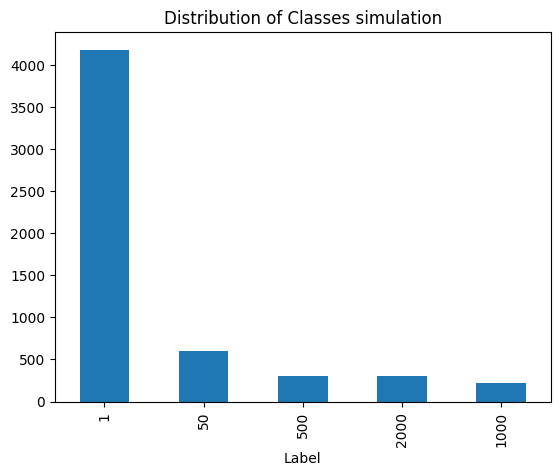

Label
1       3438
500      738
2000     737
1000     670
Name: count, dtype: int64


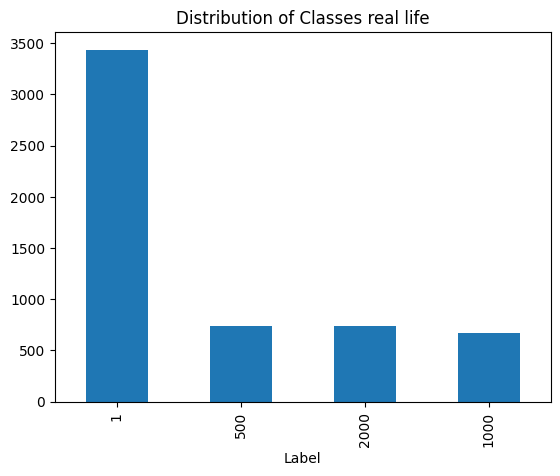

In [ ]:
_, y ,_ , y_2 = load_data(simulation, realLife,binary=False)

distrubiton = y.value_counts()

print(distrubiton)
distrubiton.plot(kind='bar')
plt.title("Distribution of Classes simulation")
plt.show()

distrubiton = y_2.value_counts()
print(distrubiton)
distrubiton.plot(kind='bar')
plt.title("Distribution of Classes real life")
plt.show()



In [ ]:
def predict_attack_type(X_input , model_detect_attack,model_detect_attack_type,
                        label_encoder=None,label_encoder2=None):
    is_attack = model_detect_attack.predict(X_input)
    is_attack = label_encoder2.inverse_transform(is_attack)
    is_attack = is_attack[0]
    if is_attack != 1:
        attack_type = model_detect_attack_type.predict(X_input)
        if label_encoder:
            attack_type = label_encoder.inverse_transform(attack_type)
        return attack_type
    else:
        return [1]


# Fonction pour créer un VotingClassifier
def create_voting_classifier(models):
    estimators = [(name, model) for name, model in models.items()]
    voting_clf = VotingClassifier(estimators=estimators, voting='soft')
    return voting_clf


# Fonction pour entraîner et évaluer les modèles
def train_and_evaluate(models, X_train, y_train, X_test, y_test):
    results = {}
    cms = {}
    for name, model in models.items():

        print(f"Training model: {name}")
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        accuracy = f1_score(y_test, predictions , average='weighted')
        results[name] = accuracy
        cms[name] = confusion_matrix(y_test, predictions)

        print(f"{name} F1 score: {accuracy:.4f}")
    return results , cms



In [ ]:
# Load your binary classification data
global_data = load_data(simulation, realLife, binary=False , split=False,shuffle=True)
global_data = global_data[global_data['Label'] != 50]
global_data.dropna(inplace=True)

X = global_data.drop(columns=['Label'])
y = global_data['Label']

label_encoder2 = LabelEncoder()
y = label_encoder2.fit_transform(y)

X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(X, y, test_size=0.3, random_state=42)

#
# models_binary = {
#        "MLP_tunning": MLPClassifier(random_state=42, max_iter=5000, hidden_layer_sizes=(90,20), activation='tanh', solver='adam', alpha=0.001, learning_rate='adaptive'),
#         "MLP_tunning2": MLPClassifier(random_state=42, max_iter=5000, hidden_layer_sizes=(100,10,20), activation='tanh', solver='adam', alpha=0.001, learning_rate='adaptive'),
#         "MLP": MLPClassifier(random_state=42, max_iter=5000),
#         "MLP_tunning3": MLPClassifier(random_state=42, max_iter=5000, hidden_layer_sizes=(100,100,100), activation='tanh', solver='adam', alpha=0.001, learning_rate='adaptive'),
#     }

models_binary = {
    "Random Forest": RandomForestClassifier(random_state=42),
    # "XGBoost": XGBClassifier( eval_metric='logloss'),
    "MLP_tunning2": MLPClassifier(random_state=42, max_iter=5000, hidden_layer_sizes=(100,10,20), activation='tanh', solver='adam', alpha=0.001, learning_rate='adaptive'),
    }
voting_model = create_voting_classifier(models_binary)
models_binary["VotingClassifier"] = voting_model
train_and_evaluate(models_binary, X_train_binary, y_train_binary, X_test_binary, y_test_binary)



Training model: Random Forest
Random Forest F1 score: 0.9947
Training model: MLP_tunning2
MLP_tunning2 F1 score: 0.9775
Training model: VotingClassifier
VotingClassifier F1 score: 0.9877


({'Random Forest': 0.9946504417507375,
  'MLP_tunning2': 0.9775257372377737,
  'VotingClassifier': 0.9876896607290511},
 {'Random Forest': array([[2286,    0,    5,    0],
         [   0,  324,    0,    2],
         [   4,    0,  262,    0],
         [   0,    6,    0,  288]]),
  'MLP_tunning2': array([[2270,    0,   21,    0],
         [   0,  319,    0,    7],
         [  30,    0,  236,    0],
         [   0,   13,    0,  281]]),
  'VotingClassifier': array([[2282,    0,    9,    0],
         [   0,  322,    0,    4],
         [  14,    0,  252,    0],
         [   0,   12,    0,  282]])})

In [ ]:
# Load your multi-class classification data
global_data = load_data(simulation, realLife, binary=False , split=False,shuffle=True)
# remove label = 1 or 50
global_data = global_data[global_data['Label'] != 1]
global_data = global_data[global_data['Label'] != 50]
global_data.dropna(inplace=True)


X = global_data.drop(columns=['Label'])
y = global_data['Label']

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X, y, test_size=0.3, random_state=42)
#
# models_multi = {
#          "MLP_tunning": MLPClassifier(random_state=42, max_iter=5000, hidden_layer_sizes=(90,20), activation='tanh', solver='adam', alpha=0.001, learning_rate='adaptive'),
#           "MLP_tunning2": MLPClassifier(random_state=42, max_iter=5000, hidden_layer_sizes=(100,10,20), activation='tanh', solver='adam', alpha=0.001, learning_rate='adaptive'),
#           "MLP": MLPClassifier(random_state=42, max_iter=5000),
#           "MLP_tunning3": MLPClassifier(random_state=42, max_iter=5000, hidden_layer_sizes=(100,100,100), activation='tanh', solver='adam', alpha=0.001, learning_rate='adaptive'),
#      }

models_multi = {
         "XGBoost": XGBClassifier( eval_metric='logloss'),
        "XGBoost_tunned": XGBClassifier( eval_metric='logloss',subsample=0.7777777777777778, n_estimators=150, max_depth=12, learning_rate=0.01, gamma=0.0, colsample_bytree=0.9444444444444444),
    "Random Forest": RandomForestClassifier(random_state=41),

     }

voting_model = create_voting_classifier(models_multi)
models_multi["VotingClassifier"] = voting_model
train_and_evaluate(models_multi, X_train_multi, y_train_multi, X_test_multi, y_test_multi)




Training model: XGBoost
XGBoost F1 score: 0.9865
Training model: XGBoost_tunned
XGBoost_tunned F1 score: 0.9809
Training model: Random Forest
Random Forest F1 score: 0.9865
Training model: VotingClassifier


/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The XGBClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


AttributeError: 'super' object has no attribute '__sklearn_tags__'

In [ ]:
# Load and preprocess the data
global_data = load_data(simulation, realLife, binary=False, split=False, shuffle=True)
global_data.dropna(inplace=True)

global_data = global_data[global_data['Label']!=50]
# Extract features and labels
X = global_data.drop(columns=['Label'])
y = global_data['Label']
print("Unique labels:", global_data['Label'].unique())

# Initialize models
model_detect_attack = models_binary["VotingClassifier"]
model_detect_attack_type = models_multi["VotingClassifier"]

# Predict using models
y_pred = []
for i in tqdm(range(len(X))):
    X_input = X.iloc[i].to_frame().T
    attack_type = predict_attack_type(X_input, model_detect_attack, model_detect_attack_type,label_encoder,label_encoder2)
    y_pred.append(attack_type[0])


print()
# Evaluate the model
from sklearn.metrics import classification_report
print(classification_report(y, y_pred,zero_division=0))



Unique labels: [   1 2000  500 1000]


  0%|          | 0/10589 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The XGBClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
  0%|          | 2/10589 [00:00<03:39, 48.22it/s]


AttributeError: 'VotingClassifier' object has no attribute 'estimators_'

In [ ]:
plot_confusion_matrix(y,y_pred,'Model cascade')


ValueError: Found input variables with inconsistent numbers of samples: [10589, 2]

In [ ]:
global_data = load_data(simulation, realLife, binary=False, split=False, shuffle=True)
global_data = global_data[global_data['Label'] != 50]
global_data.dropna(inplace=True)

X = global_data.drop(columns=['Label'])
y = global_data['Label']


model = MLPClassifier(random_state=42, max_iter=5000, hidden_layer_sizes=(100,100,100), activation='tanh', solver='adam', alpha=0.001, learning_rate='adaptive')
model.fit(X, y)
y_pred = model.predict(X)
print(classification_report(y, y_pred))




              precision    recall  f1-score   support

           1       0.98      1.00      0.99      7617
         500       0.96      0.99      0.98      1040
        1000       0.97      0.84      0.90       895
        2000       0.99      0.96      0.98      1037

    accuracy                           0.98     10589
   macro avg       0.98      0.95      0.96     10589
weighted avg       0.98      0.98      0.98     10589



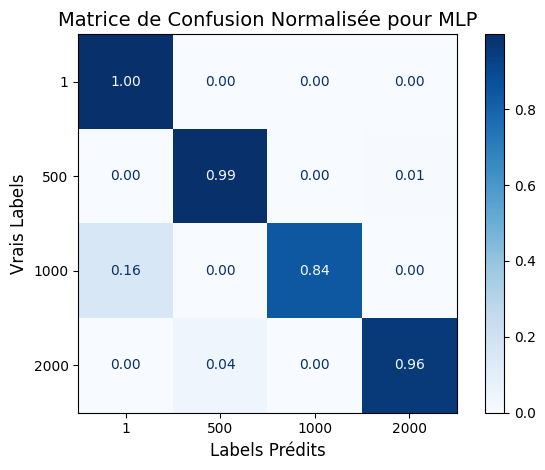

In [ ]:
plot_confusion_matrix(y, y_pred, 'MLP')

In [ ]:
from sklearn.metrics import precision_score

print("accuracy",accuracy_score(y, y_pred))


accuracy 0.9800736613466805


Training model: Random Forest
Random Forest F1 score: 0.9947
Training model: SVM
SVM F1 score: 0.7429
Training model: K-Nearest Neighbors
K-Nearest Neighbors F1 score: 0.9809
Training model: Decision Tree
Decision Tree F1 score: 0.9890
Training model: MLP tunning
MLP tunning F1 score: 0.9775
Training model: MLP
MLP F1 score: 0.9793
Training model: XGBoost
XGBoost F1 score: 0.9928
Training model: XGBoost_tunned
XGBoost_tunned F1 score: 0.9931
Training model: catboost
Learning rate set to 0.087637
0:	learn: 1.1683803	total: 11.3ms	remaining: 11.3s
1:	learn: 1.0021863	total: 18.5ms	remaining: 9.21s
2:	learn: 0.8688855	total: 25.6ms	remaining: 8.52s
3:	learn: 0.7656583	total: 32.6ms	remaining: 8.11s
4:	learn: 0.6793404	total: 39.8ms	remaining: 7.92s
5:	learn: 0.6096811	total: 47.1ms	remaining: 7.81s
6:	learn: 0.5511379	total: 54.7ms	remaining: 7.76s
7:	learn: 0.4999074	total: 61.6ms	remaining: 7.63s
8:	learn: 0.4574982	total: 68.4ms	remaining: 7.54s
9:	learn: 0.4154642	total: 75.8ms	remain

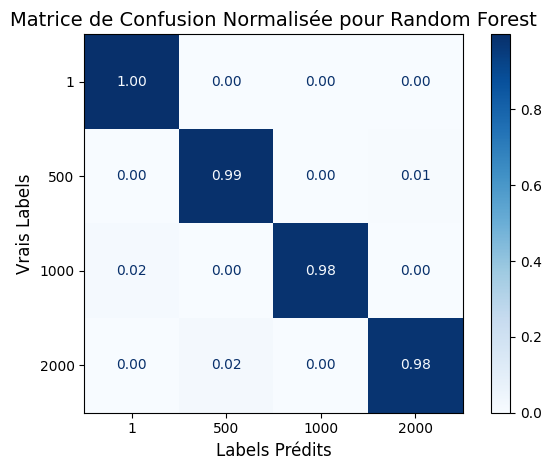

SVM 0.7428678930601138


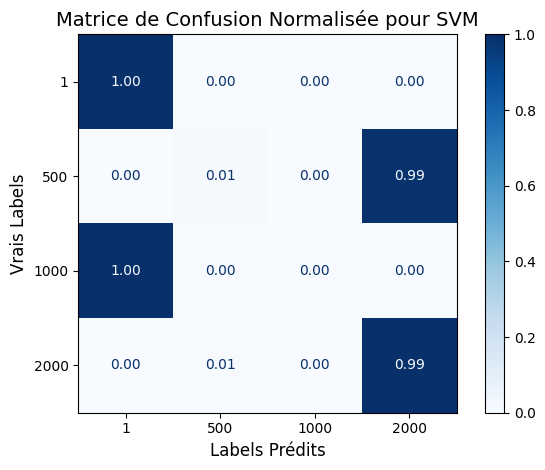

K-Nearest Neighbors 0.9808767118188176


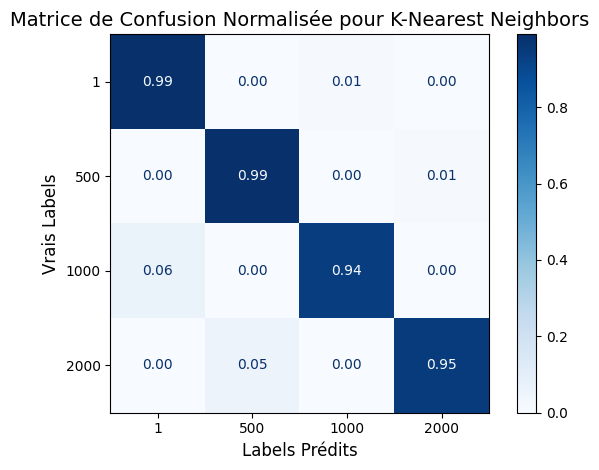

Decision Tree 0.9889559220107828


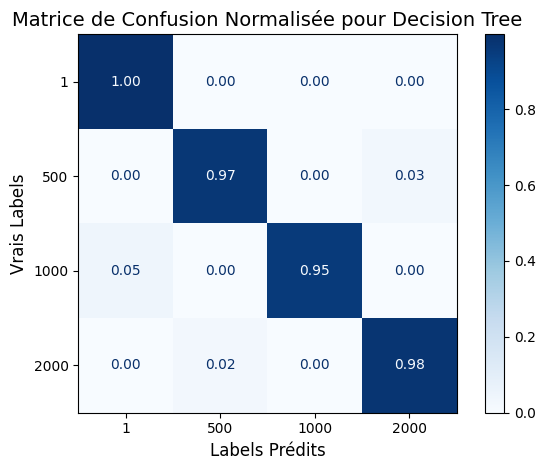

MLP tunning 0.9775257372377737


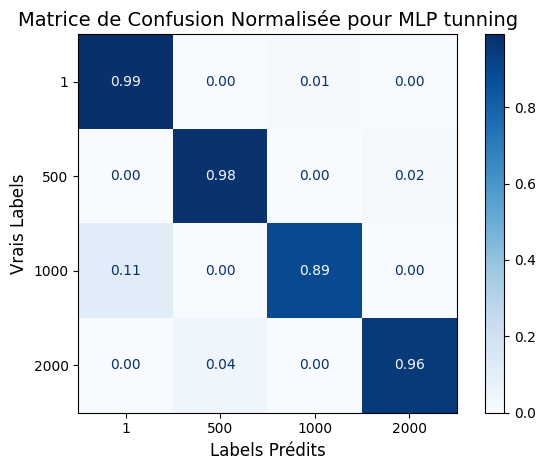

MLP 0.979293669616962


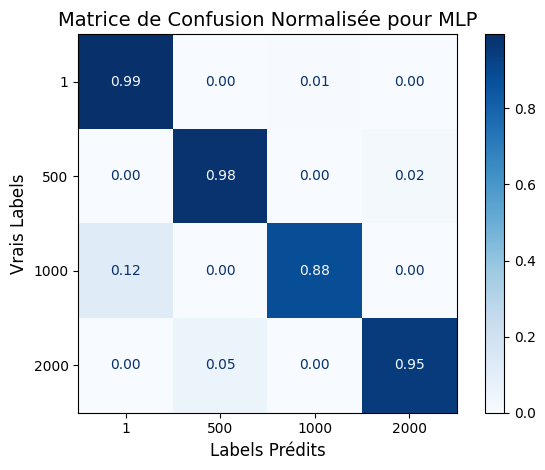

XGBoost 0.9927558761283879


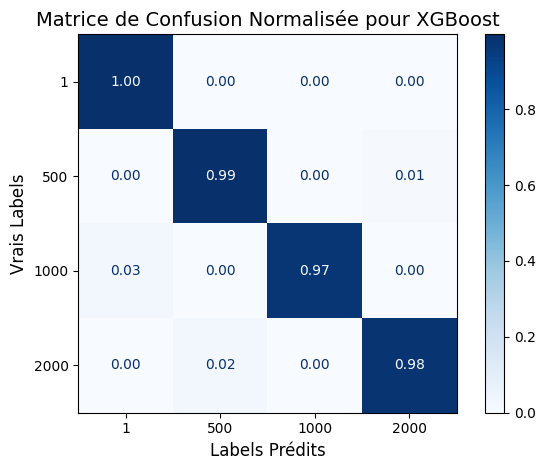

XGBoost_tunned 0.9930771495277346


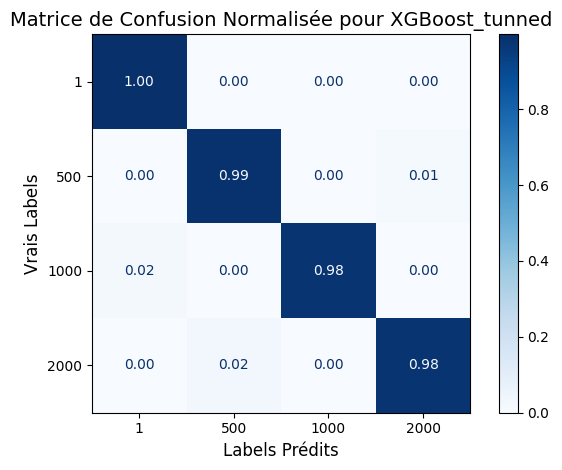

catboost 0.9940278651375232


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


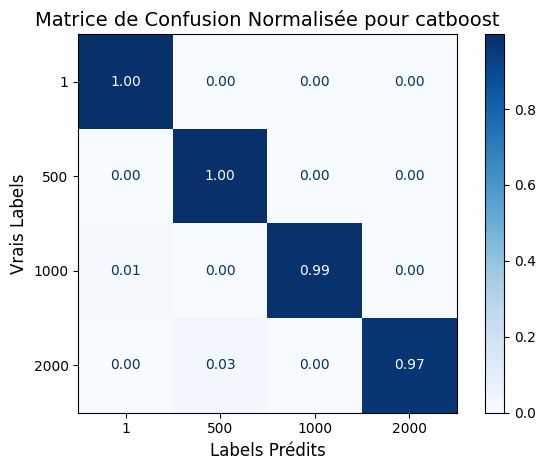

In [ ]:
global_data = load_data(simulation, realLife, binary=False, split=False, shuffle=True)
global_data = global_data[global_data['Label'] != 50]
# global_data = global_data[global_data['Label'] != 1]

global_data.dropna(inplace=True)

X = global_data.drop(columns=['Label'])
y = global_data['Label']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

models = {
        "Random Forest": RandomForestClassifier(random_state=42),
        "SVM": SVC(),
        "K-Nearest Neighbors": KNeighborsClassifier(),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        # "MLP_tunning": MLPClassifier(random_state=42, max_iter=5000, hidden_layer_sizes=(90,20), activation='tanh', solver='adam', alpha=0.001, learning_rate='adaptive'),
        "MLP tunning": MLPClassifier(random_state=42, max_iter=5000, hidden_layer_sizes=(100,10,20), activation='tanh', solver='adam', alpha=0.001, learning_rate='adaptive'),
        "MLP": MLPClassifier(random_state=42, max_iter=5000),
        "XGBoost": XGBClassifier( eval_metric='logloss'),
        "XGBoost_tunned": XGBClassifier( eval_metric='logloss',subsample=0.7777777777777778, n_estimators=150, max_depth=8, learning_rate=0.2163157894736842, gamma=0.0, colsample_bytree=0.9444444444444444),
        "catboost": CatBoostClassifier()
    }

results ,_= train_and_evaluate(models, X_train, y_train, X_test, y_test)


print(results)
# Display Results
print("\nSummary of model performances:")
for name, result in results.items():
    print(name , result)
    plot_confusion_matrix(label_encoder.inverse_transform(y_test), label_encoder.inverse_transform(models[name].predict(X_test)), name)






In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# Charger un jeu de données d'exemple
global_data = load_data(simulation, realLife, binary=False, split=False, shuffle=True)
global_data = global_data[global_data['Label'] != 50]
global_data.dropna(inplace=True)

X = global_data.drop(columns=['Label'])
y = global_data['Label']

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Diviser les données en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialiser un modèle XGBoost par défaut
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)

# Définir une grille d'hyperparamètres pour GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 1, 5]
}

# Configurer GridSearchCV pour optimiser les hyperparamètres
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, scoring='accuracy', verbose=2, n_jobs=-1)

# Ajuster le modèle GridSearchCV
grid_search.fit(X_train, y_train)

# Afficher les meilleurs paramètres trouvés
print("Meilleurs paramètres (GridSearchCV):", grid_search.best_params_)

# Évaluer le modèle avec les meilleurs paramètres
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Précision du modèle optimisé:", accuracy)

# Définir une grille d'hyperparamètres pour GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 150, 200, 300],
    'max_depth': [3, 5, 7, 9, 12],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 2, 5, 10]
}

# Configurer GridSearchCV pour optimiser les hyperparamètres
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, scoring='accuracy', verbose=2, n_jobs=-1)

# Ajuster le modèle GridSearchCV
grid_search.fit(X_train, y_train)

# Afficher les meilleurs paramètres trouvés
print("Meilleurs paramètres (GridSearchCV):", grid_search.best_params_)

# Évaluer le modèle avec les meilleurs paramètres
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Précision du modèle optimisé:", accuracy)

# Optionnel: Utiliser RandomizedSearchCV pour explorer un plus large éventail de paramètres
random_param_grid = {
    'n_estimators': np.arange(100, 500, 50),
    'max_depth': np.arange(5, 10),
    'learning_rate': np.linspace(0.01, 0.5, 20),
    'subsample': np.linspace(0.5, 1.0, 10),
    'colsample_bytree': np.linspace(0.5, 1.0, 10),
    'gamma': np.linspace(0, 10, 10)
}

random_search = RandomizedSearchCV(estimator=xgb_model, param_distributions=random_param_grid, n_iter=100, cv=3, scoring='accuracy', verbose=2, n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)

# Afficher les meilleurs paramètres trouvés par RandomizedSearchCV
print("Meilleurs paramètres (RandomizedSearchCV):", random_search.best_params_)

# Évaluer le modèle avec RandomizedSearchCV
best_random_model = random_search.best_estimator_
y_pred_random = best_random_model.predict(X_test)
accuracy_random = accuracy_score(y_test, y_pred_random)
print("Meilleurs paramètres (GridSearchCV):", grid_search.best_params_)
print("Précision du modèle optimisé (RandomizedSearchCV):", accuracy_random)

In [ ]:
print("Précision du modèle optimisé (RandomizedSearchCV):", accuracy_random)
print("Précision du modèle optimisé (GridSearchCV):", accuracy)
